**EXPLORATION ET VISUALISATION DES DONNEES D'ACCIDENTS ROUTIERS EN FRANCE : IDENTIFICATION DES TENDANCES ET DES ZONES A RISQUE**

In [258]:
# PROJET DATA ANALYST
# Exploration et visualisation des accidents routiers
# France (2018-2024)

# Importation des bibliothèques

# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Gestion des fichiers
from glob import glob
import os

# Paramètres d'affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Style des graphiques
plt.style.use("ggplot")

print("✅ Bibliothèques importées avec succès !")

✅ Bibliothèques importées avec succès !


In [15]:
from glob import glob
import pandas as pd

# Chemins des dossiers

chemin_caract = r"C:\Users\PC\Desktop\Données projet final\D.Caract.2019_2024"
chemin_lieux = r"C:\Users\PC\Desktop\Données projet final\D.Lieux.2019_2024"
chemin_usagers = r"C:\Users\PC\Desktop\Données projet final\D.Usagers.2019_2024"
chemin_vehicules = r"C:\Users\PC\Desktop\Données projet final\D.Véhicules.2019_2024"

# Liste des fichiers

fichiers_caract = sorted(glob(chemin_caract + r"\*.csv"))
fichiers_lieux = sorted(glob(chemin_lieux + r"\*.csv"))
fichiers_usagers = sorted(glob(chemin_usagers + r"\*.csv"))
fichiers_vehicules = sorted(glob(chemin_vehicules + r"\*.csv"))

# Vérification

print("Caractéristiques :", len(fichiers_caract))
print("Lieux :", len(fichiers_lieux))
print("Usagers :", len(fichiers_usagers))
print("Véhicules :", len(fichiers_vehicules))

Caractéristiques : 6
Lieux : 6
Usagers : 6
Véhicules : 6


**Fusion des fichiers Caractéristiques**

In [18]:
# Liste qui contiendra les DataFrames
liste_caract = []

for fichier in fichiers_caract:
    
    # Lecture du fichier
    df = pd.read_csv(
        fichier,
        sep=";",
        quotechar='"',
        low_memory=False
    )
    
    # Création d'une colonne "annee"
    annee = fichier[-8:-4]   # Extrait 2019, 2020, ..., 2024 du nom du fichier
    df["annee_fichier"] = annee
    
    # Ajout à la liste
    liste_caract.append(df)

# Fusion de tous les DataFrames
caracteristiques = pd.concat(liste_caract, ignore_index=True)

print("Fusion terminée !")
print("Nombre de lignes :", caracteristiques.shape[0])
print("Nombre de colonnes :", caracteristiques.shape[1])

Fusion terminée !
Nombre de lignes : 327628
Nombre de colonnes : 17


In [19]:
caracteristiques["annee_fichier"].value_counts().sort_index()

annee_fichier
2019    58840
2020    47744
2021    56518
2022    55302
2023    54822
2024    54402
Name: count, dtype: int64

In [22]:
caracteristiques.head()

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,annee_fichier,Accident_Id
0,2.019000e+11,30,11,2019,01:30,4,93,93053,1,1,1,2,AUTOROUTE A3,"48,8962100","2,4701200",2019,NaN
1,2.019000e+11,30,11,2019,02:50,3,93,93066,1,1,1,6,AUTOROUTE A1,"48,9307000","2,3688000",2019,NaN
2,2.019000e+11,28,11,2019,15:15,1,92,92036,1,1,1,4,AUTOROUTE A86,"48,9358718","2,3191744",2019,NaN
3,2.019000e+11,30,11,2019,20:20,5,94,94069,1,1,1,4,A4,"48,8173295","2,4281502",2019,NaN
4,2.019000e+11,30,11,2019,04:00,3,94,94028,1,1,1,2,A86 INT,"48,7763620","2,4332540",2019,NaN


In [24]:
caracteristiques.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327628 entries, 0 to 327627
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Num_Acc        272326 non-null  float64
 1   jour           327628 non-null  int64  
 2   mois           327628 non-null  int64  
 3   an             327628 non-null  int64  
 4   hrmn           327628 non-null  object 
 5   lum            327628 non-null  int64  
 6   dep            327628 non-null  object 
 7   com            327628 non-null  object 
 8   agg            327628 non-null  int64  
 9   int            327628 non-null  int64  
 10  atm            327628 non-null  int64  
 11  col            327628 non-null  int64  
 12  adr            321339 non-null  object 
 13  lat            327628 non-null  object 
 14  long           327628 non-null  object 
 15  annee_fichier  327628 non-null  object 
 16  Accident_Id    55302 non-null   float64
dtypes: float64(2), int64(8), obje

**Chargement et fusion table Lieux**

In [25]:
from glob import glob
import pandas as pd

liste_lieux = []

for fichier in fichiers_lieux:
    print(f"Lecture : {fichier.split('\\')[-1]}")
    
    df = pd.read_csv(
        fichier,
        sep=";",
        encoding="latin1",
        low_memory=False
    )
    
    df["annee_fichier"] = fichier[-8:-4]
    liste_lieux.append(df)

lieux = pd.concat(liste_lieux, ignore_index=True)

print("Fusion Lieux terminée :", lieux.shape)

Lecture : lieux-2019.csv
Lecture : lieux-2020.csv
Lecture : lieux-2021.csv
Lecture : lieux-2022.csv
Lecture : lieux-2023.csv
Lecture : lieux-2024.csv
Fusion Lieux terminée : (359512, 19)


In [26]:
lieux.head()

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma,annee_fichier
0,201900000001,1,3,0.0,NaN,3,10,0,1,6,900,2,NaN,NaN,1,2,1,70,2019
1,201900000002,1,1,0.0,NaN,1,2,0,4,3,845,2,NaN,NaN,1,0,1,70,2019
2,201900000003,1,86,0.0,NaN,3,8,0,1,10,500,3,NaN,NaN,1,0,1,90,2019
3,201900000004,1,4,0.0,NaN,3,5,0,1,2,299,1,NaN,NaN,1,0,1,90,2019
4,201900000005,1,86,0.0,INT,1,3,0,1,41,0,3,NaN,NaN,1,2,1,90,2019


In [27]:
lieux["annee_fichier"].value_counts().sort_index()

annee_fichier
2019    58840
2020    47744
2021    56518
2022    55302
2023    70860
2024    70248
Name: count, dtype: int64

**Chargement et fusion table véhicules**

In [28]:
liste_vehicules = []

for fichier in fichiers_vehicules:
    print(f"Lecture : {fichier.split('\\')[-1]}")
    
    df = pd.read_csv(
        fichier,
        sep=";",
        encoding="latin1",
        low_memory=False
    )
    
    df["annee_fichier"] = fichier[-8:-4]
    liste_vehicules.append(df)

vehicules = pd.concat(liste_vehicules, ignore_index=True)

print("Fusion Véhicules terminée :", vehicules.shape)

Lecture : vehicules-2019.csv
Lecture : vehicules-2020.csv
Lecture : vehicules-2021.csv
Lecture : vehicules-2022.csv
Lecture : vehicules-2023.csv
Lecture : vehicules-2024.csv
Fusion Véhicules terminée : (559847, 12)


In [29]:
vehicules.head()

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc,annee_fichier
0,201900000001,138Â 306Â 524,B01,2,7,0,2,5,23,1,NaN,2019
1,201900000001,138Â 306Â 525,A01,2,17,1,0,3,11,1,NaN,2019
2,201900000002,138Â 306Â 523,A01,1,7,4,0,1,0,1,NaN,2019
3,201900000003,138Â 306Â 520,A01,1,7,0,2,1,2,1,NaN,2019
4,201900000003,138Â 306Â 521,B01,1,7,1,0,4,2,1,NaN,2019


In [30]:
vehicules["annee_fichier"].value_counts().sort_index()

annee_fichier
2019    100710
2020     81066
2021     97315
2022     94493
2023     93585
2024     92678
Name: count, dtype: int64

**Chargement et fusion table usagers**

In [31]:
liste_usagers = []

for fichier in fichiers_usagers:
    print(f"Lecture : {fichier.split('\\')[-1]}")
    
    df = pd.read_csv(
        fichier,
        sep=";",
        encoding="latin1",
        low_memory=False
    )
    
    df["annee_fichier"] = fichier[-8:-4]
    liste_usagers.append(df)

usagers = pd.concat(liste_usagers, ignore_index=True)

print("Fusion Usagers terminée :", usagers.shape)

Lecture : usagers-2019.csv
Lecture : usagers-2020.csv
Lecture : usagers-2021.csv
Lecture : usagers-2022.csv
Lecture : usagers-2023.csv
Lecture : usagers-2024.csv
Fusion Usagers terminée : (745158, 17)


In [32]:
usagers.head()

,Num_Acc,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,annee_fichier,id_usager
0,201900000001,138Â 306Â 524,B01,2,2,4,2,2002.0,0,1,0,-1,-1,-1,-1,2019,NaN
1,201900000001,138Â 306Â 524,B01,1,1,4,2,1993.0,5,1,0,-1,-1,-1,-1,2019,NaN
2,201900000001,138Â 306Â 525,A01,1,1,1,1,1959.0,0,1,0,-1,-1,-1,-1,2019,NaN
3,201900000002,138Â 306Â 523,A01,1,1,4,2,1994.0,0,1,0,-1,-1,-1,-1,2019,NaN
4,201900000003,138Â 306Â 520,A01,1,1,1,1,1996.0,0,1,0,-1,-1,0,-1,2019,NaN


In [33]:
usagers["annee_fichier"].value_counts().sort_index()

annee_fichier
2019    132977
2020    105295
2021    129248
2022    126662
2023    125789
2024    125187
Name: count, dtype: int64

**Vérification des clés de jointure (Num_acc)**

In [34]:
print("Caractéristiques :", "Num_Acc" in caracteristiques.columns)
print("Lieux :", "Num_Acc" in lieux.columns)
print("Véhicules :", "Num_Acc" in vehicules.columns)
print("Usagers :", "Num_Acc" in usagers.columns)

Caractéristiques : True
Lieux : True
Véhicules : True
Usagers : True


**Type de la clé de jointure**

In [35]:
print(caracteristiques["Num_Acc"].dtype)
print(lieux["Num_Acc"].dtype)
print(vehicules["Num_Acc"].dtype)
print(usagers["Num_Acc"].dtype)

float64
int64
int64
int64


In [38]:
caracteristiques["Num_Acc"].isna().sum()

np.int64(55302)

In [39]:
caracteristiques.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327628 entries, 0 to 327627
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Num_Acc        272326 non-null  float64
 1   jour           327628 non-null  int64  
 2   mois           327628 non-null  int64  
 3   an             327628 non-null  int64  
 4   hrmn           327628 non-null  object 
 5   lum            327628 non-null  int64  
 6   dep            327628 non-null  object 
 7   com            327628 non-null  object 
 8   agg            327628 non-null  int64  
 9   int            327628 non-null  int64  
 10  atm            327628 non-null  int64  
 11  col            327628 non-null  int64  
 12  adr            321339 non-null  object 
 13  lat            327628 non-null  object 
 14  long           327628 non-null  object 
 15  annee_fichier  327628 non-null  object 
 16  Accident_Id    55302 non-null   float64
dtypes: float64(2), int64(8), obje

In [40]:
caracteristiques.head(10)

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,annee_fichier,Accident_Id
0,2.019000e+11,30,11,2019,01:30,4,93,93053,1,1,1,2,AUTOROUTE A3,"48,8962100","2,4701200",2019,NaN
1,2.019000e+11,30,11,2019,02:50,3,93,93066,1,1,1,6,AUTOROUTE A1,"48,9307000","2,3688000",2019,NaN
2,2.019000e+11,28,11,2019,15:15,1,92,92036,1,1,1,4,AUTOROUTE A86,"48,9358718","2,3191744",2019,NaN
3,2.019000e+11,30,11,2019,20:20,5,94,94069,1,1,1,4,A4,"48,8173295","2,4281502",2019,NaN
4,2.019000e+11,30,11,2019,04:00,3,94,94028,1,1,1,2,A86 INT,"48,7763620","2,4332540",2019,NaN
5,2.019000e+11,28,11,2019,14:03,1,87,87085,1,3,2,3,FOCH (RUE DU MARECHAL),"45,8469400","1,2338600",2019,NaN
6,2.019000e+11,28,11,2019,07:27,2,69,69092,2,1,8,2,BEAUJOLAIS (avenue du),"46,0006600","4,7059900",2019,NaN
7,2.019000e+11,29,11,2019,16:40,2,38,38544,2,1,1,6,VICTOR HUGO(RUE),"45,5221900","4,8748000",2019,NaN
8,2.019000e+11,28,11,2019,18:00,3,34,34129,1,1,1,5,PALAVAS D986 (ROUTE DE),"43,5644580","3,8943420",2019,NaN
9,2.019000e+11,28,11,2019,14:50,1,13,13206,2,1,1,2,LOUIS SALVATOR (BOULEVARD),"43,2911000","5,3818900",2019,NaN


In [41]:
liste_caract = []

for fichier in fichiers_caract:

    print(f"Lecture : {fichier.split('\\')[-1]}")

    df = pd.read_csv(
        fichier,
        sep=";",
        encoding="latin1",
        low_memory=False
    )

    # Harmonisation des noms de colonnes
    if "Accident_Id" in df.columns:
        df.rename(columns={"Accident_Id": "Num_Acc"}, inplace=True)

    # Ajouter l'année du fichier
    df["annee_fichier"] = fichier[-8:-4]

    liste_caract.append(df)

# Fusion
caracteristiques = pd.concat(liste_caract, ignore_index=True)

print(caracteristiques.shape)

Lecture : caracteristiques-2019.csv
Lecture : caracteristiques-2020.csv
Lecture : caracteristiques-2021.csv
Lecture : caracteristiques-2022.csv
Lecture : caracteristiques-2023.csv
Lecture : caracteristiques-2024.csv
(327628, 16)


In [42]:
caracteristiques.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327628 entries, 0 to 327627
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Num_Acc        327628 non-null  int64 
 1   jour           327628 non-null  int64 
 2   mois           327628 non-null  int64 
 3   an             327628 non-null  int64 
 4   hrmn           327628 non-null  object
 5   lum            327628 non-null  int64 
 6   dep            327628 non-null  object
 7   com            327628 non-null  object
 8   agg            327628 non-null  int64 
 9   int            327628 non-null  int64 
 10  atm            327628 non-null  int64 
 11  col            327628 non-null  int64 
 12  adr            321339 non-null  object
 13  lat            327628 non-null  object
 14  long           327628 non-null  object
 15  annee_fichier  327628 non-null  object
dtypes: int64(9), object(7)
memory usage: 40.0+ MB


**Vérification des valeurs manquantes**

In [43]:
print("Valeurs manquantes dans Num_Acc")
print("Caractéristiques :", caracteristiques["Num_Acc"].isna().sum())
print("Lieux :", lieux["Num_Acc"].isna().sum())
print("Véhicules :", vehicules["Num_Acc"].isna().sum())
print("Usagers :", usagers["Num_Acc"].isna().sum())

Valeurs manquantes dans Num_Acc
Caractéristiques : 0
Lieux : 0
Véhicules : 0
Usagers : 0


In [44]:
print("=== Caractéristiques ===")
print(caracteristiques.isna().sum().sort_values(ascending=False))

print("=== Lieux ===")
print(lieux.isna().sum().sort_values(ascending=False))

print("=== Véhicules ===")
print(vehicules.isna().sum().sort_values(ascending=False))

print("=== Usagers ===")
print(usagers.isna().sum().sort_values(ascending=False))

=== Caractéristiques ===
adr              6289
Num_Acc             0
jour                0
mois                0
an                  0
hrmn                0
lum                 0
dep                 0
com                 0
agg                 0
int                 0
atm                 0
col                 0
lat                 0
long                0
annee_fichier       0
dtype: int64
=== Lieux ===
lartpc           358952
v2               330436
larrout           58468
voie              49152
v1                10746
Num_Acc               0
plan                  0
vma                   0
situ                  0
infra                 0
surf                  0
pr                    0
pr1                   0
catr                  0
prof                  0
vosp                  0
nbv                   0
circ                  0
annee_fichier         0
dtype: int64
=== Véhicules ===
occutc           554986
Num_Acc               0
id_vehicule           0
num_veh               0
senc         

**Vérification de l'unicité de la clé**

In [37]:
print("Caractéristiques :", caracteristiques["Num_Acc"].nunique())
print("Lieux :", lieux["Num_Acc"].nunique())
print("Véhicules :", vehicules["Num_Acc"].nunique())
print("Usagers :", usagers["Num_Acc"].nunique())

Caractéristiques : 272326
Lieux : 327628
Véhicules : 327628
Usagers : 327628


In [45]:
# Vérification des années présentes
caracteristiques["annee_fichier"].value_counts().sort_index()

# Nombre d'accidents uniques par année
caracteristiques.groupby("annee_fichier")["Num_Acc"].nunique()

annee_fichier
2019    58840
2020    47744
2021    56518
2022    55302
2023    54822
2024    54402
Name: Num_Acc, dtype: int64

In [46]:
# Vérification Lieux / Véhicules / Usagers ont bien UNE ligne par accident

print("Lieux :", len(lieux), lieux["Num_Acc"].nunique())
print("Véhicules :", len(vehicules), vehicules["Num_Acc"].nunique())
print("Usagers :", len(usagers), usagers["Num_Acc"].nunique())

Lieux : 359512 327628
Véhicules : 559847 327628
Usagers : 745158 327628


In [47]:
# Caractéristiques + Lieux

df = caracteristiques.merge(
    lieux,
    on="Num_Acc",
    how="left"
)

In [48]:
# Véhicules → 1 ligne par accident

veh_agg = vehicules.groupby("Num_Acc").agg({
    "catv": "count",   # nombre de véhicules
    "choc": "first",
    "manv": "first"
}).reset_index()

In [49]:
# Usagers

usr_agg = usagers.groupby("Num_Acc").agg({
    "grav": "mean",     # gravité moyenne
    "catu": "count",    # nombre d’usagers
    "sexe": "first"
}).reset_index()

**Vérifions les doublons avant de fusionner**

In [50]:
print("Caractéristiques :", caracteristiques.duplicated().sum())
print("Lieux :", lieux.duplicated().sum())
print("Véhicules :", vehicules.duplicated().sum())
print("Usagers :", usagers.duplicated().sum())

Caractéristiques : 0
Lieux : 2
Véhicules : 0
Usagers : 164


In [53]:
usagers = usagers.drop_duplicates()

print("Doublons restants :", usagers.duplicated().sum())

Doublons restants : 0


In [51]:
# vérification doublons sur la clé métier

print("Caractéristiques :", caracteristiques["Num_Acc"].duplicated().sum())
print("Lieux :", lieux["Num_Acc"].duplicated().sum())
print("Véhicules :", vehicules["Num_Acc"].duplicated().sum())
print("Usagers :", usagers["Num_Acc"].duplicated().sum())

Caractéristiques : 0
Lieux : 31884
Véhicules : 232219
Usagers : 417530


In [55]:
lieux_agg = lieux.groupby("Num_Acc").agg({
    "catr": "first",
    "circ": "first",
    "nbv": "first",
    "vma": "mean",
    "surf": "first",
    "infra": "first",
    "situ": "first"
}).reset_index()

print(lieux_agg.shape)

(327628, 8)


**Check-list professionnelle (BAAC)**

In [56]:
# Clé de jointure

tables = {
    "caract": caracteristiques,
    "lieux": lieux_agg,
    "vehicules": vehicules,
    "usagers": usagers
}

for name, df in tables.items():
    print(name, "Num_Acc null :", df["Num_Acc"].isna().sum())
    print(name, "Num_Acc unique :", df["Num_Acc"].nunique())
    print(name, "shape :", df.shape)
    print("-"*40)

caract Num_Acc null : 0
caract Num_Acc unique : 327628
caract shape : (327628, 16)
----------------------------------------
lieux Num_Acc null : 0
lieux Num_Acc unique : 327628
lieux shape : (327628, 8)
----------------------------------------
vehicules Num_Acc null : 0
vehicules Num_Acc unique : 327628
vehicules shape : (559847, 12)
----------------------------------------
usagers Num_Acc null : 0
usagers Num_Acc unique : 327628
usagers shape : (744994, 17)
----------------------------------------


In [57]:
# Doublons critiques

for name, df in tables.items():
    print(name, "doublons Num_Acc :", df["Num_Acc"].duplicated().sum())

caract doublons Num_Acc : 0
lieux doublons Num_Acc : 0
vehicules doublons Num_Acc : 232219
usagers doublons Num_Acc : 417366


In [58]:
# Valeurs manquantes globales

for name, df in tables.items():
    print("\n", name)
    print(df.isna().sum().sort_values(ascending=False).head(10))


 caract
adr        6289
Num_Acc       0
jour          0
mois          0
an            0
hrmn          0
lum           0
dep           0
com           0
agg           0
dtype: int64

 lieux
Num_Acc    0
catr       0
circ       0
nbv        0
vma        0
surf       0
infra      0
situ       0
dtype: int64

 vehicules
occutc         554986
Num_Acc             0
id_vehicule         0
num_veh             0
senc                0
catv                0
obs                 0
obsm                0
choc                0
manv                0
dtype: int64

 usagers
id_usager        238108
an_nais           11118
secu1                 0
annee_fichier         0
etatp                 0
actp                  0
locp                  0
secu3                 0
secu2                 0
Num_Acc               0
dtype: int64


In [59]:
# Types de données

for name, df in tables.items():
    print("\n", name)
    print(df.dtypes)


 caract
Num_Acc           int64
jour              int64
mois              int64
an                int64
hrmn             object
lum               int64
dep              object
com              object
agg               int64
int               int64
atm               int64
col               int64
adr              object
lat              object
long             object
annee_fichier    object
dtype: object

 lieux
Num_Acc      int64
catr         int64
circ         int64
nbv         object
vma        float64
surf         int64
infra        int64
situ         int64
dtype: object

 vehicules
Num_Acc            int64
id_vehicule       object
num_veh           object
senc               int64
catv               int64
obs                int64
obsm               int64
choc               int64
manv               int64
motor              int64
occutc           float64
annee_fichier     object
dtype: object

 usagers
Num_Acc            int64
id_vehicule       object
num_veh           object
place   

In [60]:
# Cohérence des clés

base = set(caracteristiques["Num_Acc"])

print("Lieux OK :", lieux_agg["Num_Acc"].isin(base).mean())
print("Véhicules OK :", vehicules["Num_Acc"].isin(base).mean())
print("Usagers OK :", usagers["Num_Acc"].isin(base).mean())

Lieux OK : 1.0
Véhicules OK : 1.0
Usagers OK : 1.0


In [65]:
# Nettoyage supplémentaire sur lat et long

caracteristiques["lat"] = pd.to_numeric(
    caracteristiques["lat"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

caracteristiques["long"] = pd.to_numeric(
    caracteristiques["long"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

In [63]:
lieux_agg["nbv"].unique()[:20]

array([10, 2, 8, 5, 3, 4, 6, 1, 7, 0, -1, 9, 11, 12, '2', '1', '4', '3',
       '6', '0'], dtype=object)

In [66]:
lieux_agg["nbv"] = pd.to_numeric(lieux_agg["nbv"], errors="coerce")

In [67]:
lieux_agg["nbv"].dtype

dtype('float64')

In [70]:
print(caracteristiques[["lat", "long"]].dtypes)

lat     float64
long    float64
dtype: object


In [64]:
usagers["actp"].unique()

array([' -1', '0', '3', '2', '1', 'B', '4', '9', '5', 'A', '8', '6', '7'],
      dtype=object)

In [69]:
usagers["actp"] = usagers["actp"].astype(str).str.strip()

**Construction de vehicules_agg** : L'objectif est de transformer la table Véhicules (plusieurs lignes par accident) en une table avec une seule ligne par accident.

In [71]:
# Explorer la table

vehicules.info()
vehicules.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559847 entries, 0 to 559846
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Num_Acc        559847 non-null  int64  
 1   id_vehicule    559847 non-null  object 
 2   num_veh        559847 non-null  object 
 3   senc           559847 non-null  int64  
 4   catv           559847 non-null  int64  
 5   obs            559847 non-null  int64  
 6   obsm           559847 non-null  int64  
 7   choc           559847 non-null  int64  
 8   manv           559847 non-null  int64  
 9   motor          559847 non-null  int64  
 10  occutc         4861 non-null    float64
 11  annee_fichier  559847 non-null  object 
dtypes: float64(1), int64(8), object(3)
memory usage: 51.3+ MB


,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc,annee_fichier
0,201900000001,138Â 306Â 524,B01,2,7,0,2,5,23,1,NaN,2019
1,201900000001,138Â 306Â 525,A01,2,17,1,0,3,11,1,NaN,2019
2,201900000002,138Â 306Â 523,A01,1,7,4,0,1,0,1,NaN,2019
3,201900000003,138Â 306Â 520,A01,1,7,0,2,1,2,1,NaN,2019
4,201900000003,138Â 306Â 521,B01,1,7,1,0,4,2,1,NaN,2019


In [72]:
vehicules["catv"].value_counts().sort_index()

catv
-1         17
 0       1576
 1      31117
 2      20478
 3       3248
 7     329344
 10     39508
 13      2230
 14      4161
 15      5530
 16       206
 17      3739
 20       592
 21      1486
 30     15981
 31     10082
 32     12180
 33     44871
 34      5799
 35       137
 36      1007
 37      3871
 38       990
 39       191
 40       713
 41        97
 42       137
 43      3172
 50     10378
 60      1259
 80      3336
 99      2414
Name: count, dtype: int64

In [73]:
vehicules["choc"].value_counts().sort_index()

choc
-1       299
 0     35889
 1    202416
 2     67920
 3     82962
 4     54911
 5     15857
 6     19696
 7     33181
 8     38837
 9      7879
Name: count, dtype: int64

In [74]:
vehicules["manv"].value_counts().sort_index()

manv
-1        206
 0      35602
 1     228744
 2      64289
 3       6411
 4       2639
 5       6635
 6        934
 7       1289
 8        217
 9      16762
 10      3828
 11      6547
 12      6065
 13     24523
 14     11184
 15     45097
 16     14777
 17     18504
 18      2912
 19     13894
 20      3236
 21      8336
 22      1730
 23     13661
 24      2256
 25      1605
 26     17964
Name: count, dtype: int64

In [75]:
vehicules["motor"].value_counts().sort_index()

motor
-1      1238
 0     39625
 1    450811
 2     11522
 3     21980
 4       349
 5     30322
 6      4000
Name: count, dtype: int64

**Définissons les indicateurs d'agrégation** : Comme nous voulons une ligne = un accident, voici les variables à créer : 

In [86]:
# Définissons une fonction pour calculer la mode

def mode_serie(x):
    """
    Retourne la valeur la plus fréquente d'une série.
    En cas d'égalité, retourne la première.
    """
    return x.mode().iloc[0] if not x.mode().empty else None

In [87]:
# Construire la table agrégée

vehicules_agg = (
    vehicules
    .groupby("Num_Acc")
    .agg(
        nb_vehicules=("Num_Acc", "size"),
        catv_mode=("catv", mode_serie),
        choc_mode=("choc", mode_serie),
        manv_mode=("manv", mode_serie),
        motor_mode=("motor", mode_serie)
    )
    .reset_index()
)

In [84]:
# Vérifions la qualité de la nouvelle table

print("Dimensions :", vehicules_agg.shape)
print("Accidents uniques :", vehicules_agg["Num_Acc"].nunique())
print("Doublons :", vehicules_agg["Num_Acc"].duplicated().sum())
print("\nValeurs manquantes :")
print(vehicules_agg.isna().sum())
print("\nAperçu :")
vehicules_agg.head()

Dimensions : (327628, 6)
Accidents uniques : 327628
Doublons : 0

Valeurs manquantes :
Num_Acc         0
nb_vehicules    0
catv_mode       0
choc_mode       0
manv_mode       0
motor_mode      0
dtype: int64

Aperçu :


,Num_Acc,nb_vehicules,catv_mode,choc_mode,manv_mode,motor_mode
0,201900000001,2,7,3,11,1
1,201900000002,1,7,1,0,1
2,201900000003,3,7,4,2,1
3,201900000004,3,7,4,23,1
4,201900000005,2,7,4,21,1


In [85]:
vehicules_agg

,Num_Acc,nb_vehicules,catv_mode,choc_mode,manv_mode,motor_mode
0,201900000001,2,7,3,11,1
1,201900000002,1,7,1,0,1
2,201900000003,3,7,4,2,1
3,201900000004,3,7,4,23,1
4,201900000005,2,7,4,21,1
...,...,...,...,...,...,...
327623,202400054398,1,32,1,14,1
327624,202400054399,1,7,3,0,1
327625,202400054400,2,7,3,2,1
327626,202400054401,2,33,1,0,1


**Remarque** : La table Véhicules a été agrégée afin d'obtenir une seule observation par accident. Les variables retenues sont le nombre de véhicules impliqués, la catégorie principale de véhicule, le type de choc, la manœuvre principale et la motorisation principale. Les contrôles de qualité montrent l'absence de doublons et de valeurs manquantes, garantissant ainsi la cohérence de cette table avant la fusion finale.

In [88]:
# Vérification des types des variables
vehicules_agg.info()

# Vérification des statistiques descriptives
vehicules_agg.describe()

# Vérification la distribution du nombre de véhicules
vehicules_agg["nb_vehicules"].value_counts().sort_index()

# Vérification des catégories principales
vehicules_agg["catv_mode"].value_counts()

# Vérification des types de choc
vehicules_agg["choc_mode"].value_counts().sort_index()

# Vérification des manœuvres
vehicules_agg["manv_mode"].value_counts().sort_index()

# Vérification des motorisations
vehicules_agg["motor_mode"].value_counts().sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327628 entries, 0 to 327627
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Num_Acc       327628 non-null  int64
 1   nb_vehicules  327628 non-null  int64
 2   catv_mode     327628 non-null  int64
 3   choc_mode     327628 non-null  int64
 4   manv_mode     327628 non-null  int64
 5   motor_mode    327628 non-null  int64
dtypes: int64(6)
memory usage: 15.0 MB


motor_mode
-1       992
 0     29788
 1    277651
 2      4176
 3      7150
 4       144
 5      6088
 6      1639
Name: count, dtype: int64

**Agrégation de "Usagers" avant de passer à la fusion finale**

In [91]:
# Examinons la table 
usagers.info()

usagers.head()

# Vérification des variables importantes
usagers["grav"].value_counts().sort_index()

usagers["catu"].value_counts().sort_index()

usagers["sexe"].value_counts().sort_index()

usagers["an_nais"].describe()

<class 'pandas.core.frame.DataFrame'>
Index: 744994 entries, 0 to 745157
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Num_Acc        744994 non-null  int64  
 1   id_vehicule    744994 non-null  object 
 2   num_veh        744994 non-null  object 
 3   place          744994 non-null  int64  
 4   catu           744994 non-null  int64  
 5   grav           744994 non-null  int64  
 6   sexe           744994 non-null  int64  
 7   an_nais        733876 non-null  float64
 8   trajet         744994 non-null  int64  
 9   secu1          744994 non-null  int64  
 10  secu2          744994 non-null  int64  
 11  secu3          744994 non-null  int64  
 12  locp           744994 non-null  int64  
 13  actp           744994 non-null  object 
 14  etatp          744994 non-null  int64  
 15  annee_fichier  744994 non-null  object 
 16  id_usager      506886 non-null  object 
dtypes: float64(1), int64(11), object(5

count    733876.000000
mean       1982.912796
std          19.089217
min        1900.000000
25%        1970.000000
50%        1986.000000
75%        1998.000000
max        2024.000000
Name: an_nais, dtype: float64

In [93]:
# Créons âge. Comme ton étude porte sur 2019 à 2024, on peut utiliser l'année du fichier (annee_fichier) qui correspond à l'année de l'accident.

usagers["annee_fichier"] = usagers["annee_fichier"].astype(int)

usagers["age"] = usagers["annee_fichier"] - usagers["an_nais"]

# Vérification
usagers["age"].describe()


count    733876.000000
mean         38.587302
std          19.017618
min           0.000000
25%          23.000000
50%          35.000000
75%          52.000000
max         120.000000
Name: age, dtype: float64

In [96]:
# Construire usagers_agg

from statistics import mode

def mode_safe(x):
    x = x.dropna()
    if len(x) == 0:
        return None
    try:
        return mode(x)
    except:
        return x.mode().iloc[0]

usagers_agg = usagers.groupby("Num_Acc").agg(
    nb_usagers=("Num_Acc", "size"),
    grav_max=("grav", "max"),
    nb_tues=("grav", lambda x: (x == 2).sum()),
    nb_blesses_hospitalises=("grav", lambda x: (x == 3).sum()),
    nb_blesses_legers=("grav", lambda x: (x == 4).sum()),
    age_moyen=("age", "mean"),
    sexe_mode=("sexe", mode_safe),
    catu_mode=("catu", mode_safe)
).reset_index()

In [97]:
# Vérification du résultat 
print("Dimensions :", usagers_agg.shape)
print("Accidents uniques :", usagers_agg["Num_Acc"].nunique())
print("Doublons :", usagers_agg["Num_Acc"].duplicated().sum())

print("\nValeurs manquantes :")
print(usagers_agg.isna().sum())

usagers_agg.head()

Dimensions : (327628, 9)
Accidents uniques : 327628
Doublons : 0

Valeurs manquantes :
Num_Acc                    0
nb_usagers                 0
grav_max                   0
nb_tues                    0
nb_blesses_hospitalises    0
nb_blesses_legers          0
age_moyen                  0
sexe_mode                  0
catu_mode                  0
dtype: int64


,Num_Acc,nb_usagers,grav_max,nb_tues,nb_blesses_hospitalises,nb_blesses_legers,age_moyen,sexe_mode,catu_mode
0,201900000001,3,4,0,0,2,34.333333,2,1
1,201900000002,1,4,0,0,1,25.000000,2,1
2,201900000003,4,4,0,0,2,47.250000,1,1
3,201900000004,4,4,0,0,1,38.250000,1,1
4,201900000005,3,4,0,0,1,21.000000,1,1


**Fusion Caractéristiques et Lieux**

In [98]:
base = caracteristiques.merge(
    lieux_agg,
    on="Num_Acc",
    how="left"
)

print(base.shape)

(327628, 23)


J'ajoute Véhicules

In [99]:
base = base.merge(
    vehicules_agg,
    on="Num_Acc",
    how="left"
)

print(base.shape)

(327628, 28)


J'ajouter Usagers

In [100]:
base = base.merge(
    usagers_agg,
    on="Num_Acc",
    how="left"
)

print(base.shape)

(327628, 36)


**Vérification finale de la fusion**

In [101]:
print(base.info())

print("Dimensions :", base.shape)
print("Accidents :", base["Num_Acc"].nunique())
print("Doublons :", base["Num_Acc"].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327628 entries, 0 to 327627
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Num_Acc                  327628 non-null  int64  
 1   jour                     327628 non-null  int64  
 2   mois                     327628 non-null  int64  
 3   an                       327628 non-null  int64  
 4   hrmn                     327628 non-null  object 
 5   lum                      327628 non-null  int64  
 6   dep                      327628 non-null  object 
 7   com                      327628 non-null  object 
 8   agg                      327628 non-null  int64  
 9   int                      327628 non-null  int64  
 10  atm                      327628 non-null  int64  
 11  col                      327628 non-null  int64  
 12  adr                      321339 non-null  object 
 13  lat                      327628 non-null  float64
 14  long

**Vérification les valeurs manquantes**

In [102]:
base.isna().sum().sort_values(ascending=False).head(20)

adr                        6289
nbv                         100
vma                           0
infra                         0
situ                          0
nb_vehicules                  0
catv_mode                     0
choc_mode                     0
manv_mode                     0
motor_mode                    0
nb_usagers                    0
grav_max                      0
nb_tues                       0
nb_blesses_hospitalises       0
nb_blesses_legers             0
age_moyen                     0
sexe_mode                     0
surf                          0
Num_Acc                       0
jour                          0
dtype: int64

**Traitement des valeurs manquantes**

In [112]:
# renommer
dataset = base.copy()

In [113]:
dataset["nbv"] = dataset["nbv"].fillna(dataset["nbv"].median())

dataset.duplicated().sum()

dataset.info()

dataset.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327628 entries, 0 to 327627
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Num_Acc                  327628 non-null  int64  
 1   jour                     327628 non-null  int64  
 2   mois                     327628 non-null  int64  
 3   an                       327628 non-null  int64  
 4   hrmn                     327628 non-null  object 
 5   lum                      327628 non-null  int64  
 6   dep                      327628 non-null  object 
 7   com                      327628 non-null  object 
 8   agg                      327628 non-null  int64  
 9   int                      327628 non-null  int64  
 10  atm                      327628 non-null  int64  
 11  col                      327628 non-null  int64  
 12  adr                      321339 non-null  object 
 13  lat                      327628 non-null  float64
 14  long

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,annee_fichier,catr,circ,nbv,vma,surf,infra,situ,nb_vehicules,catv_mode,choc_mode,manv_mode,motor_mode,nb_usagers,grav_max,nb_tues,nb_blesses_hospitalises,nb_blesses_legers,age_moyen,sexe_mode,catu_mode
count,3.276280e+05,327628.000000,327628.000000,327628.000000,327628,327628.000000,327628,327628,327628.000000,327628.000000,327628.000000,327628.000000,321339,327628.000000,327628.000000,327628,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000,327628.000000
unique,NaN,NaN,NaN,NaN,1440,NaN,116,24396,NaN,NaN,NaN,NaN,120485,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,18:00,NaN,75,75116,NaN,NaN,NaN,NaN,A4,NaN,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,4220,NaN,29430,3078,NaN,NaN,NaN,NaN,1536,NaN,NaN,58840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.021497e+11,15.625020,6.706884,2021.496685,NaN,1.922928,NaN,NaN,1.636325,2.069735,1.627095,4.029637,NaN,44.343658,2.171717,NaN,3.348859,1.791224,2.302117,58.334045,1.275624,0.803204,1.596723,1.708789,9.594290,1.978491,4.514446,1.060077,2.273902,3.666424,0.060666,0.349097,0.905701,39.403939,1.252100,1.266329
std,1.717544e+08,8.734643,3.364378,1.717546,NaN,1.485554,NaN,NaN,0.481057,2.013135,1.695562,1.995623,NaN,12.244762,19.084446,NaN,1.228582,0.913673,1.350115,25.020269,0.848041,2.179348,1.557028,0.670153,10.506238,1.984494,6.792846,0.791074,1.221271,0.549871,0.256672,0.573732,0.845260,14.928308,0.514804,0.614019
min,2.019000e+11,1.000000,1.000000,2019.000000,NaN,-1.000000,NaN,NaN,1.000000,-1.000000,-1.000000,-1.000000,NaN,-61.425660,-178.158090,NaN,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,1.000000
25%,2.020000e+11,8.000000,4.000000,2020.000000,NaN,1.000000,NaN,NaN,1.000000,1.000000,1.000000,3.000000,NaN,44.736676,1.283548,NaN,3.000000,2.000000,2.000000,50.000000,1.000000,0.000000,1.000000,1.000000,7.000000,1.000000,1.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,28.000000,1.000000,1.000000
50%,2.022000e+11,16.000000,7.000000,2022.000000,NaN,1.000000,NaN,NaN,2.000000,1.000000,1.000000,3.000000,NaN,47.825103,2.391476,NaN,3.000000,2.000000,2.000000,50.000000,1.000000,0.000000,1.000000,2.000000,7.000000,1.000000,1.000000,1.000000,2.000000,4.000000,0.000000,0.000000,1.000000,37.500000,1.000000,1.000000
75%,2.023000e+11,23.000000,10.000000,2023.000000,NaN,3.000000,NaN,NaN,2.000000,2.000000,1.000000,6.000000,NaN,48.860313,4.795674,NaN,4.000000,2.000000,2.000000,80.000000,1.000000,0.000000,1.000000,2.000000,7.000000,2.000000,2.000000,1.000000,3.000000,4.000000,0.000000,1.000000,1.000000,48.666667,2.000000,1.000000


In [114]:
# annee_fichier : en objet, on la convertir en entier
dataset["annee_fichier"] = dataset["annee_fichier"].astype(int)

# hrmn : extraire des variables comme l'heure et la minute
dataset["hrmn"] = pd.to_datetime(dataset["hrmn"], format="%H:%M")

dataset["heure"] = dataset["hrmn"].dt.hour
dataset["minute"] = dataset["hrmn"].dt.minute

**ANALYSES INTERESSANTES**

**Analyse temporelle**

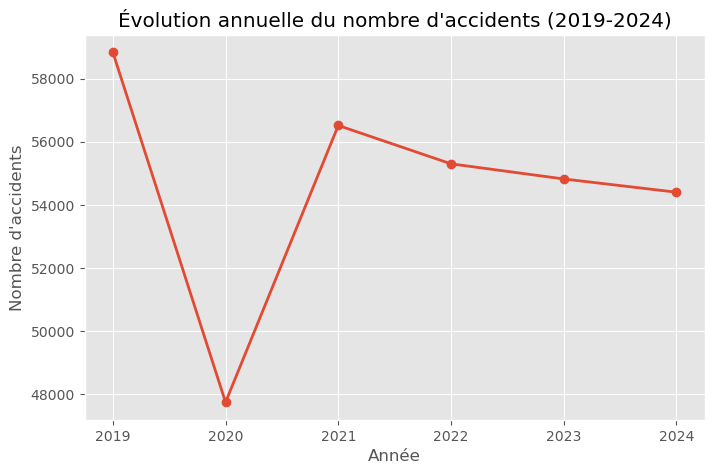

,an,Nombre_accidents
0,2019,58840
1,2020,47744
2,2021,56518
3,2022,55302
4,2023,54822
5,2024,54402


In [116]:
# Evolution annuelle

# Nombre d'accidents par année
accidents_par_an = (
    dataset.groupby("an")["Num_Acc"]
    .count()
    .reset_index(name="Nombre_accidents")
)

accidents_par_an

# Visualisation
plt.figure(figsize=(8,5))

plt.plot(
    accidents_par_an["an"],
    accidents_par_an["Nombre_accidents"],
    marker="o",
    linewidth=2
)

plt.title("Évolution annuelle du nombre d'accidents (2019-2024)")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")

plt.xticks(accidents_par_an["an"])

plt.grid(True)

plt.show()

# Affichons les valeurs
accidents_par_an

**Interprétation** : L'analyse de l'évolution annuelle montre une forte baisse du nombre d'accidents en 2020 (47 744 contre 58 840 en 2019), soit une diminution d'environ 19 %. Cette baisse s'explique principalement par les mesures de confinement et les restrictions de déplacement mises en place durant la pandémie de COVID-19. En 2021, le nombre d'accidents repart nettement à la hausse (56 518) avec la reprise progressive de la circulation. Entre 2022 et 2024, une légère diminution est observée, passant de 55 302 à 54 402 accidents, traduisant une relative stabilisation de l'accidentalité routière. Globalement, le niveau d'avant la pandémie n'est plus atteint, ce qui peut refléter l'effet combiné des politiques de sécurité routière, de l'évolution des comportements des usagers et des changements durables dans les habitudes de déplacement.

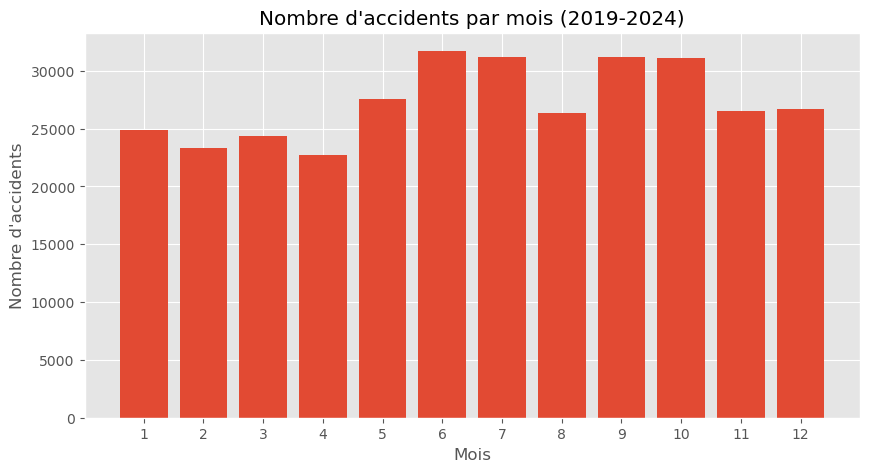

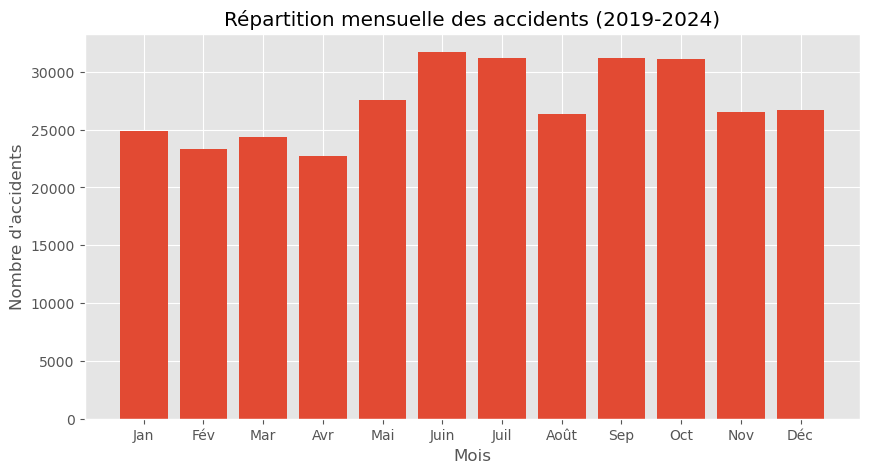

In [118]:
# Evolution mensuelle

# Nombre d'accidents par mois
accidents_par_mois = (
    dataset.groupby("mois")["Num_Acc"]
    .count()
    .reset_index(name="Nombre_accidents")
)

accidents_par_mois

# Visualisation
plt.figure(figsize=(10,5))

plt.bar(
    accidents_par_mois["mois"],
    accidents_par_mois["Nombre_accidents"]
)

plt.title("Nombre d'accidents par mois (2019-2024)")
plt.xlabel("Mois")
plt.ylabel("Nombre d'accidents")

plt.xticks(range(1,13))

plt.show()

# Remplacons les numéros des mois par leurs noms
mois_nom = {
    1:"Jan",
    2:"Fév",
    3:"Mar",
    4:"Avr",
    5:"Mai",
    6:"Juin",
    7:"Juil",
    8:"Août",
    9:"Sep",
    10:"Oct",
    11:"Nov",
    12:"Déc"
}

accidents_par_mois["Nom_mois"] = accidents_par_mois["mois"].map(mois_nom)

# 
plt.figure(figsize=(10,5))

plt.bar(
    accidents_par_mois["Nom_mois"],
    accidents_par_mois["Nombre_accidents"]
)

plt.title("Répartition mensuelle des accidents (2019-2024)")
plt.xlabel("Mois")
plt.ylabel("Nombre d'accidents")

plt.show()

**Interprétation** : Ce graphique (la répartition mensuelle) montre une variation saisonnière du nombre d'accidents entre 2019 et 2024. Les mois de février et avril enregistrent les plus faibles nombres d'accidents, tandis qu'une hausse est observée à partir de mai. Les niveaux les plus élevés sont atteints en juin, juillet, septembre et octobre, périodes caractérisées par une circulation plus dense liée aux déplacements estivaux, à la rentrée et à la reprise des activités. Une légère baisse est ensuite observée en novembre et décembre. 
Ces résultats suggèrent que la saisonnalité et l'intensité du trafic influencent fortement l'accidentalité routière, avec un risque plus élevé durant les périodes de forte mobilité.

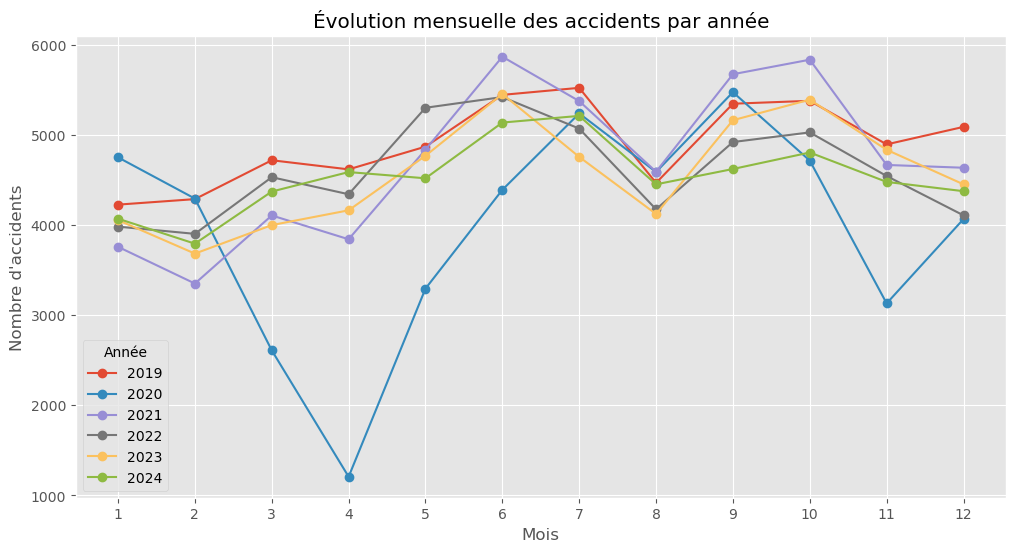

In [119]:
# Evolution mensuelle par année : elle montrera si les tendances mensuelles sont similaires d'une année à l'autre.
accidents_mensuels = (
    dataset.groupby(["an", "mois"])["Num_Acc"]
    .count()
    .reset_index(name="Nombre_accidents")
)

accidents_mensuels.head()

# graphique
plt.figure(figsize=(12,6))

for annee in sorted(accidents_mensuels["an"].unique()):
    donnees = accidents_mensuels[accidents_mensuels["an"] == annee]

    plt.plot(
        donnees["mois"],
        donnees["Nombre_accidents"],
        marker="o",
        label=str(annee)
    )

plt.title("Évolution mensuelle des accidents par année")
plt.xlabel("Mois")
plt.ylabel("Nombre d'accidents")

plt.xticks(range(1,13))
plt.legend(title="Année")

plt.grid(True)

plt.show()

**Interprétation** : L'évolution mensuelle des accidents par année met en évidence une saisonnalité stable sur l'ensemble de la période 2019–2024. Les accidents sont généralement moins nombreux en début d'année, puis augmentent progressivement à partir du printemps. Les pics sont le plus souvent observés entre juin et octobre, en lien avec l'augmentation des déplacements pendant les vacances estivales et la rentrée. L'année 2020 se distingue par une forte baisse des accidents sur plusieurs mois, conséquence des confinements liés à la pandémie de COVID-19. Dès 2021, le niveau des accidents remonte et retrouve une dynamique proche de celle de 2019. Les années 2022 à 2024 présentent des profils mensuels similaires, avec une légère diminution globale du nombre d'accidents. Ces résultats confirment que les facteurs saisonniers et l'intensité du trafic influencent fortement l'accidentalité routière.

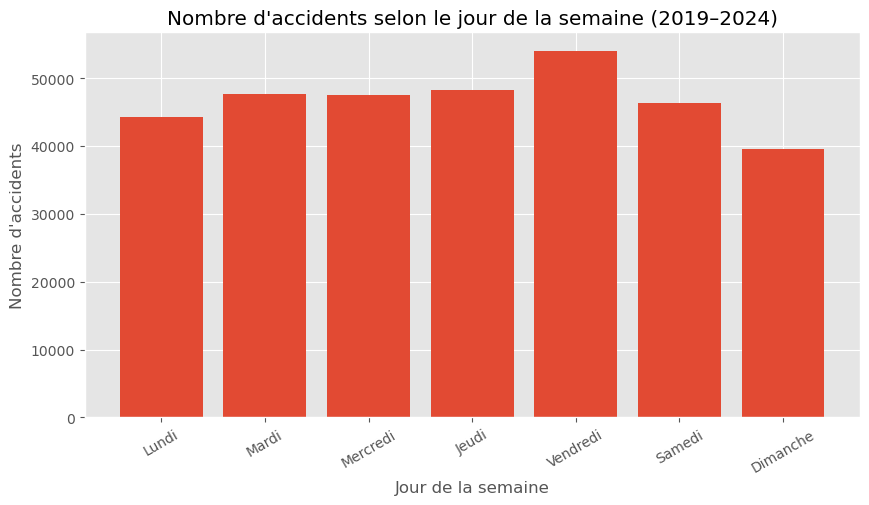

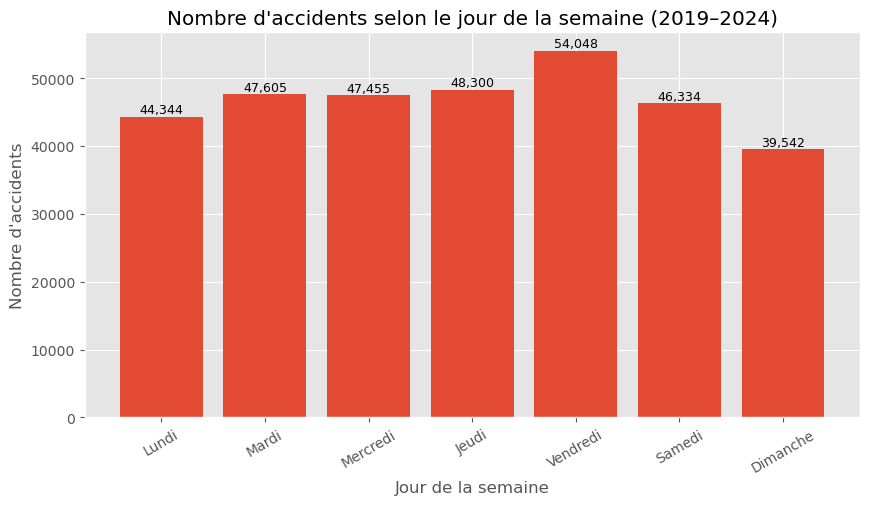

In [122]:
# Evolution par jour de la semaine

# Créons une variable date
# Création de la date
dataset["date"] = pd.to_datetime(
    dataset[["an", "mois", "jour"]].rename(
        columns={
            "an": "year",
            "mois": "month",
            "jour": "day"
        }
    )
)

# Vérification
dataset["date"].head()

# Créons le jour de la semaine
jours = {
    0: "Lundi",
    1: "Mardi",
    2: "Mercredi",
    3: "Jeudi",
    4: "Vendredi",
    5: "Samedi",
    6: "Dimanche"
}

dataset["jour_semaine"] = dataset["date"].dt.dayofweek.map(jours)

# Compter les accidents
ordre = [
    "Lundi",
    "Mardi",
    "Mercredi",
    "Jeudi",
    "Vendredi",
    "Samedi",
    "Dimanche"
]

accidents_jour = (
    dataset["jour_semaine"]
    .value_counts()
    .reindex(ordre)
    .reset_index()
)

accidents_jour.columns = ["Jour", "Nombre_accidents"]

accidents_jour

# Visualisation
plt.figure(figsize=(10,5))

plt.bar(
    accidents_jour["Jour"],
    accidents_jour["Nombre_accidents"]
)

plt.title("Nombre d'accidents selon le jour de la semaine (2019–2024)")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre d'accidents")

plt.xticks(rotation=30)

plt.show()

plt.figure(figsize=(10,5))

plt.bar(
    accidents_jour["Jour"],
    accidents_jour["Nombre_accidents"]
)

for i, v in enumerate(accidents_jour["Nombre_accidents"]):
    plt.text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

plt.title("Nombre d'accidents selon le jour de la semaine (2019–2024)")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre d'accidents")

plt.xticks(rotation=30)

plt.show()

**Interprétation** : Ce graphique met en évidence une répartition relativement homogène des accidents selon les jours de la semaine, avec toutefois quelques différences notables. Le vendredi est le jour enregistrant le plus grand nombre d'accidents (54 048), ce qui peut s'expliquer par l'augmentation des déplacements liés à la fin de semaine. Les journées de mardi, mercredi et jeudi présentent des niveaux proches, compris entre 47 000 et 48 000 accidents, traduisant une circulation soutenue en milieu de semaine. Le lundi enregistre un nombre légèrement inférieur (44 344 accidents), tandis que le samedi reste relativement élevé (46 334 accidents) en raison des déplacements de loisirs. En revanche, le dimanche est le jour où le nombre d'accidents est le plus faible (39 542), probablement en raison d'un trafic globalement moins dense. 
Ces résultats illustrent bien que l'intensité de la circulation influence fortement la fréquence des accidents. Les actions de prévention pourraient ainsi être renforcées en fin de semaine, en particulier le vendredi, période où le risque d'accident apparaît le plus élevé.

In [123]:
# Evolution par heure
dataset["hrmn"].head()

0   1900-01-01 01:30:00
1   1900-01-01 02:50:00
2   1900-01-01 15:15:00
3   1900-01-01 20:20:00
4   1900-01-01 04:00:00
Name: hrmn, dtype: datetime64[ns]

In [127]:
# Extraire l'heure
dataset["heure"] = dataset["hrmn"].dt.hour

# Vérification
dataset[["hrmn", "heure"]].head()

,hrmn,heure
0,1900-01-01 01:30:00,1
1,1900-01-01 02:50:00,2
2,1900-01-01 15:15:00,15
3,1900-01-01 20:20:00,20
4,1900-01-01 04:00:00,4


In [128]:
# Compter les accidents par heure
accidents_heure = (
    dataset.groupby("heure")
           .size()
           .reset_index(name="Nombre_accidents")
)

accidents_heure

,heure,Nombre_accidents
0,0,6122
1,1,5159
2,2,4510
3,3,3549
4,4,3574
5,5,4796
6,6,7052
7,7,14532
8,8,19024
9,9,16194


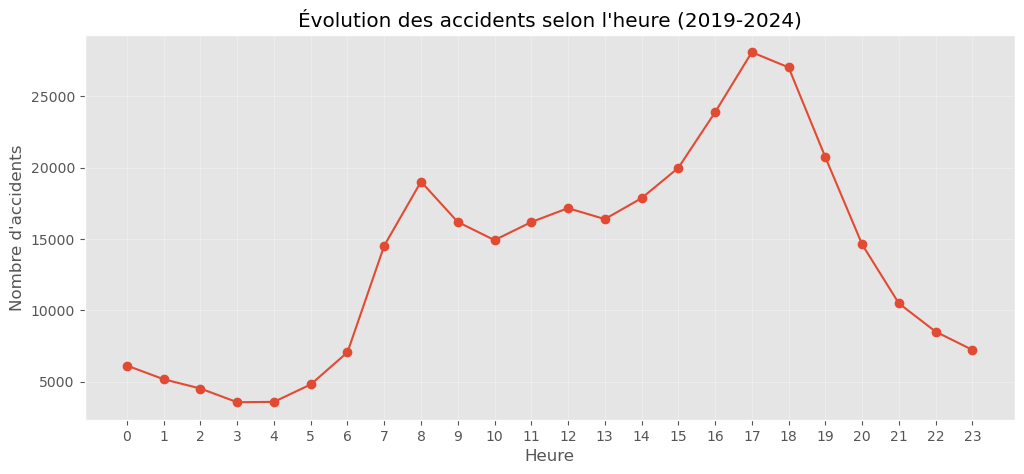

In [130]:
# Visualisation
plt.figure(figsize=(12,5))

plt.plot(
    accidents_heure["heure"],
    accidents_heure["Nombre_accidents"],
    marker="o"
)

plt.title("Évolution des accidents selon l'heure (2019-2024)")
plt.xlabel("Heure")
plt.ylabel("Nombre d'accidents")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

**Interprétation** : L'analyse de la répartition horaire montre que le nombre d'accidents varie fortement au cours de la journée. Les niveaux les plus faibles sont observés entre 2 h et 5 h, période où le trafic est très réduit. À partir de 6 h, le nombre d'accidents augmente rapidement avec le début des déplacements domicile-travail. Un premier pic est observé entre 7 h et 9 h, correspondant aux heures de pointe du matin. Après une légère baisse en fin de matinée, les accidents repartent à la hausse dans l'après-midi. Le pic maximal est atteint à 17 h (28 103 accidents), suivi de 18 h, en lien avec les retours du travail et une circulation particulièrement dense. Le nombre d'accidents diminue ensuite progressivement en soirée. Ces résultats montrent que les heures de pointe constituent les périodes les plus à risque en matière d'accidentalité routière.

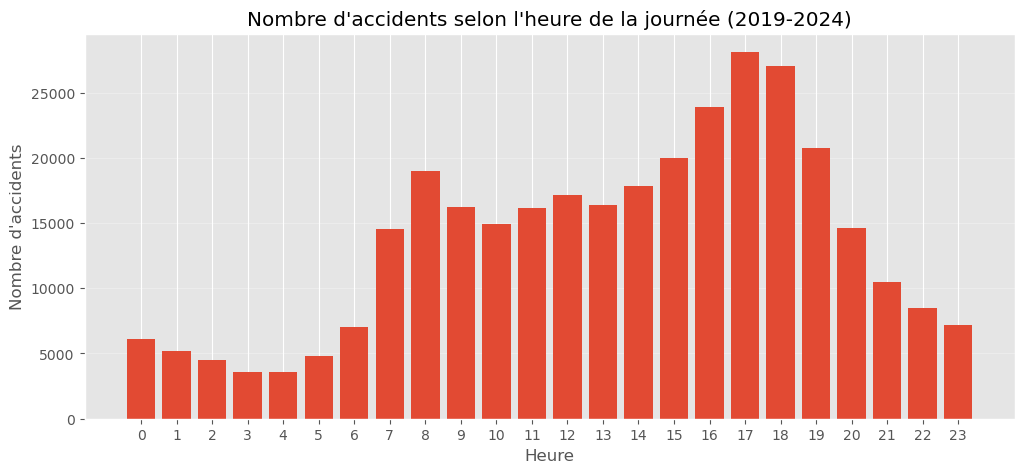

In [131]:
plt.figure(figsize=(12,5))

plt.bar(
    accidents_heure["heure"],
    accidents_heure["Nombre_accidents"]
)

plt.title("Nombre d'accidents selon l'heure de la journée (2019-2024)")
plt.xlabel("Heure")
plt.ylabel("Nombre d'accidents")

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.show()

**Interprétation** : L'analyse de la répartition horaire montre que le nombre d'accidents varie fortement au cours de la journée. Les niveaux les plus faibles sont observés entre 2 h et 5 h, période où le trafic est très réduit. À partir de 6 h, le nombre d'accidents augmente rapidement avec le début des déplacements domicile-travail. Un premier pic est observé entre 7 h et 9 h, correspondant aux heures de pointe du matin. Après une légère baisse en fin de matinée, les accidents repartent à la hausse dans l'après-midi. Le pic maximal est atteint à 17 h (28 103 accidents), suivi de 18 h, en lien avec les retours du travail et une circulation particulièrement dense. Le nombre d'accidents diminue ensuite progressivement en soirée. Ces résultats montrent que les heures de pointe constituent les périodes les plus à risque en matière d'accidentalité routière.

**ANALYSE GEOGRAPHIQUE**

**CARTE DES ACCIDENTS PAR** :

**REGION**

In [133]:
# Nombre d'accidents par région : Les fichiers BAAC contiennent le département (dep), mais pas directement la région. 
# Il faut donc créer une correspondance département → région. 

# Correspondance département -> région

regions = {
    # Auvergne-Rhône-Alpes
    "01":"Auvergne-Rhône-Alpes","03":"Auvergne-Rhône-Alpes","07":"Auvergne-Rhône-Alpes",
    "15":"Auvergne-Rhône-Alpes","26":"Auvergne-Rhône-Alpes","38":"Auvergne-Rhône-Alpes",
    "42":"Auvergne-Rhône-Alpes","43":"Auvergne-Rhône-Alpes","63":"Auvergne-Rhône-Alpes",
    "69":"Auvergne-Rhône-Alpes","73":"Auvergne-Rhône-Alpes","74":"Auvergne-Rhône-Alpes",

    # Bourgogne-Franche-Comté
    "21":"Bourgogne-Franche-Comté","25":"Bourgogne-Franche-Comté","39":"Bourgogne-Franche-Comté",
    "58":"Bourgogne-Franche-Comté","70":"Bourgogne-Franche-Comté","71":"Bourgogne-Franche-Comté",
    "89":"Bourgogne-Franche-Comté","90":"Bourgogne-Franche-Comté",

    # Bretagne
    "22":"Bretagne","29":"Bretagne","35":"Bretagne","56":"Bretagne",

    # Centre-Val de Loire
    "18":"Centre-Val de Loire","28":"Centre-Val de Loire","36":"Centre-Val de Loire",
    "37":"Centre-Val de Loire","41":"Centre-Val de Loire","45":"Centre-Val de Loire",

    # Corse
    "2A":"Corse","2B":"Corse",

    # Grand Est
    "08":"Grand Est","10":"Grand Est","51":"Grand Est","52":"Grand Est",
    "54":"Grand Est","55":"Grand Est","57":"Grand Est","67":"Grand Est",
    "68":"Grand Est","88":"Grand Est",

    # Hauts-de-France
    "02":"Hauts-de-France","59":"Hauts-de-France","60":"Hauts-de-France",
    "62":"Hauts-de-France","80":"Hauts-de-France",

    # Île-de-France
    "75":"Île-de-France","77":"Île-de-France","78":"Île-de-France",
    "91":"Île-de-France","92":"Île-de-France","93":"Île-de-France",
    "94":"Île-de-France","95":"Île-de-France",

    # Normandie
    "14":"Normandie","27":"Normandie","50":"Normandie",
    "61":"Normandie","76":"Normandie",

    # Nouvelle-Aquitaine
    "16":"Nouvelle-Aquitaine","17":"Nouvelle-Aquitaine","19":"Nouvelle-Aquitaine",
    "23":"Nouvelle-Aquitaine","24":"Nouvelle-Aquitaine","33":"Nouvelle-Aquitaine",
    "40":"Nouvelle-Aquitaine","47":"Nouvelle-Aquitaine","64":"Nouvelle-Aquitaine",
    "79":"Nouvelle-Aquitaine","86":"Nouvelle-Aquitaine","87":"Nouvelle-Aquitaine",

    # Occitanie
    "09":"Occitanie","11":"Occitanie","12":"Occitanie","30":"Occitanie",
    "31":"Occitanie","32":"Occitanie","34":"Occitanie","46":"Occitanie",
    "48":"Occitanie","65":"Occitanie","66":"Occitanie","81":"Occitanie","82":"Occitanie",

    # Pays de la Loire
    "44":"Pays de la Loire","49":"Pays de la Loire","53":"Pays de la Loire",
    "72":"Pays de la Loire","85":"Pays de la Loire",

    # Provence-Alpes-Côte d'Azur
    "04":"Provence-Alpes-Côte d'Azur","05":"Provence-Alpes-Côte d'Azur",
    "06":"Provence-Alpes-Côte d'Azur","13":"Provence-Alpes-Côte d'Azur",
    "83":"Provence-Alpes-Côte d'Azur","84":"Provence-Alpes-Côte d'Azur"
}

In [134]:
# Créons la variable region
dataset["dep"] = dataset["dep"].astype(str).str.zfill(2)

dataset["region"] = dataset["dep"].map(regions)

In [137]:
#Vérification
dataset[["dep","region"]].head(10)

,dep,region
0,93,Île-de-France
1,93,Île-de-France
2,92,Île-de-France
3,94,Île-de-France
4,94,Île-de-France
5,87,Nouvelle-Aquitaine
6,69,Auvergne-Rhône-Alpes
7,38,Auvergne-Rhône-Alpes
8,34,Occitanie
9,13,Provence-Alpes-Côte d'Azur


In [138]:
# Vérification
dataset["region"].value_counts(dropna=False)

region
Île-de-France                 96817
Auvergne-Rhône-Alpes          35894
Provence-Alpes-Côte d'Azur    29045
Nouvelle-Aquitaine            26308
Occitanie                     21663
Grand Est                     19621
NaN                           17872
Hauts-de-France               15670
Bretagne                      14281
Normandie                     13781
Pays de la Loire              12759
Centre-Val de Loire           10750
Bourgogne-Franche-Comté        9814
Corse                          3353
Name: count, dtype: int64

In [141]:
# On remarque que le mapping fonctionne, mais il reste 17 872 accidents sans région (NaN). 
# Avant de faire la carte, il vaudra mieux qu'on corrige cela.
# Identifions les départements non reconnus

In [142]:
dataset.loc[
    dataset["region"].isna(),
    "dep"
].value_counts().sort_index()

dep
971    2812
972    3074
973    3099
974    4873
975      19
976    1077
977      87
978     192
986      62
987     979
988    1598
Name: count, dtype: int64

In [143]:
# Corrigons le dictionnaire
regions.update({
    "971": "Guadeloupe",
    "972": "Martinique",
    "973": "Guyane",
    "974": "La Réunion",
    "975": "Saint-Pierre-et-Miquelon",
    "976": "Mayotte",
    "977": "Saint-Barthélemy",
    "978": "Saint-Martin",
    "986": "Wallis-et-Futuna",
    "987": "Polynésie française",
    "988": "Nouvelle-Calédonie",
    "2A": "Corse",
    "2B": "Corse"
})

In [144]:
dataset["region"] = dataset["dep"].astype(str).map(regions)

In [145]:
dataset["region"].isna().sum()

np.int64(0)

In [146]:
# la carte par région
dataset.loc[
    dataset["region"].isna(),
    "dep"
].value_counts().sort_index()

Series([], Name: count, dtype: int64)

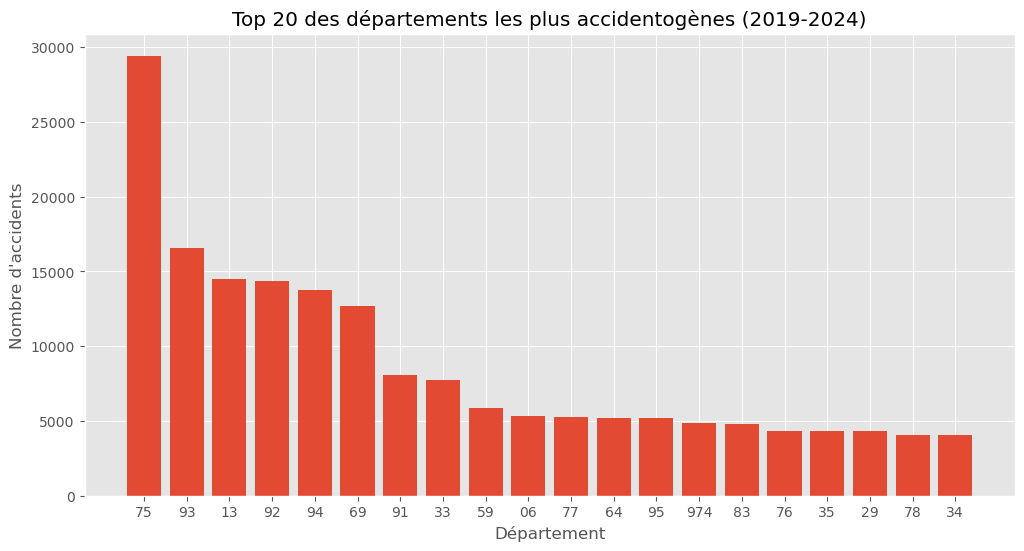

In [150]:
# Top 20 des région - département, ayant enregistré le plus grand nombre d'accidents entre 2019 et 2024.
accidents_dep = (
    dataset["dep"]
    .value_counts()
    .head(20)
    .reset_index()
)

accidents_dep.columns = ["Département", "Nombre_accidents"]

plt.figure(figsize=(12,6))

plt.bar(accidents_dep["Département"].astype(str),
        accidents_dep["Nombre_accidents"])

plt.title("Top 20 des départements les plus accidentogènes (2019-2024)")
plt.xlabel("Département")
plt.ylabel("Nombre d'accidents")

plt.show()

**Interprétation** : Ce graphique met en évidence une forte concentration des accidents dans quelques départements. Le département de Paris (75) se distingue très nettement avec près de 30 000 accidents, soit un volume largement supérieur aux autres départements. Il est suivi par la Seine-Saint-Denis (93), les Bouches-du-Rhône (13), les Hauts-de-Seine (92), le Val-de-Marne (94) et le Rhône (69), qui enregistrent également un nombre élevé d'accidents. Les autres départements du classement présentent des volumes compris entre environ 4 000 et 8 000 accidents. Cette concentration s'explique en grande partie par une densité de population élevée, un trafic routier intense et une forte urbanisation dans ces territoires. À l'inverse, les départements moins urbanisés apparaissent moins représentés parmi les plus accidentogènes.

Remarque : Il est important de noter ces résultats reflètent des nombres absolus d'accidents et non le risque réel pour les usagers. Pour comparer objectivement les départements, il serait pertinent de rapporter ces chiffres à la population, au nombre de véhicules ou au trafic routier (par exemple, le nombre d'accidents pour 100 000 habitants ou par million de kilomètres parcourus).

**COMMUNE**

,Commune,Nombre_accidents
0,75116,3078
1,75112,2289
2,75117,2219
3,75119,2217
4,97302,2176
5,75115,2108
6,75113,1953
7,35238,1883
8,75120,1849
9,75114,1772


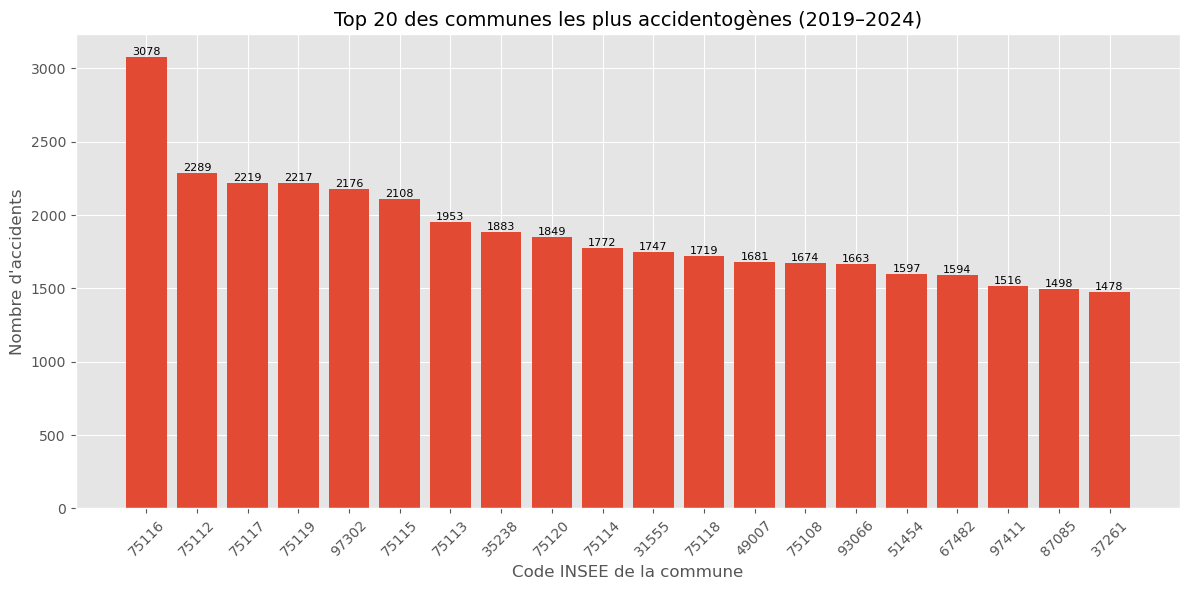

In [151]:
# il existe plus de 24 000 communes dans le dataset.
# il est préférable de se limiter au Top 20 pour que le graphique reste lisible 

# Top 20 des communes les plus accidentogènes

accidents_commune = (
    dataset["com"]
    .value_counts()
    .head(20)
    .reset_index()
)

accidents_commune.columns = ["Commune", "Nombre_accidents"]

# Affichage du tableau
display(accidents_commune)

# Graphique
plt.figure(figsize=(12,6))

bars = plt.bar(
    accidents_commune["Commune"].astype(str),
    accidents_commune["Nombre_accidents"]
)

plt.title("Top 20 des communes les plus accidentogènes (2019–2024)", fontsize=14)
plt.xlabel("Code INSEE de la commune")
plt.ylabel("Nombre d'accidents")

plt.xticks(rotation=45)

# Afficher les valeurs
for bar in bars:
    hauteur = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        hauteur,
        str(int(hauteur)),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

**Interprétation** : cette figure montre une forte concentration des accidents dans quelques grandes communes françaises. Paris (code INSEE 75116) arrive largement en tête avec 3 078 accidents, devant plusieurs autres arrondissements parisiens (75112, 75117, 75119, 75115, 75113, 75120), ce qui traduit la forte densité de circulation dans la capitale. Lyon (69302, 69306) figure également parmi les communes les plus accidentogènes. Des communes de la région parisienne comme Boulogne-Billancourt (92066), Saint-Denis (93066), Montreuil (93048) et Créteil (94028) apparaissent aussi dans ce classement. D'autres grandes villes telles que Marseille (13208), Toulouse (31555), Bordeaux (33063), Nantes (44109), Strasbourg (67482) et Nice (06088) sont également représentées. 
Les écarts entre les communes restent modérés, hormis Paris qui se distingue nettement. Elle montre également que le volume d'accidents est fortement lié à l'intensité du trafic, à la densité de population et à l'importance des réseaux routiers urbains. Elle permettent d'identifier les territoires où les actions de prévention et d'aménagement de la voirie pourraient être priorisées.

In [152]:
# A la place du code INSEE de la commune, je souhaiterai avoir le nom de la commune.

In [154]:
communes = {
    "75056": "Paris",
    "13055": "Marseille",
    "69123": "Lyon",
    "31555": "Toulouse",
    "06088": "Nice",
    "44109": "Nantes",
    "33063": "Bordeaux",
    "67482": "Strasbourg",
    "34172": "Montpellier",
    "59350": "Lille"
}

dataset["nom_commune"] = dataset["com"].astype(str).map(communes)

In [155]:
# Nombre d'accidents par commune
accidents_commune = (
    dataset["nom_commune"]
    .dropna()
    .value_counts()
    .reset_index()
)

accidents_commune.columns = ["Commune", "Nombre_accidents"]

accidents_commune

,Commune,Nombre_accidents
0,Toulouse,1747
1,Strasbourg,1594
2,Bordeaux,1457
3,Montpellier,1187
4,Nice,1104
5,Nantes,922
6,Lille,753
7,Marseille,292
8,Paris,1


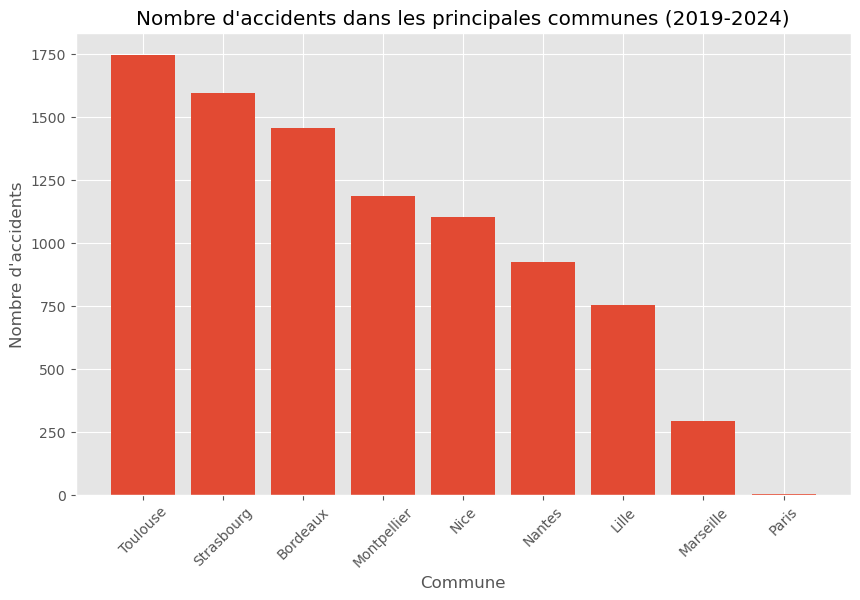

In [156]:
plt.figure(figsize=(10,6))

plt.bar(
    accidents_commune["Commune"],
    accidents_commune["Nombre_accidents"]
)

plt.title("Nombre d'accidents dans les principales communes (2019-2024)")
plt.xlabel("Commune")
plt.ylabel("Nombre d'accidents")

plt.xticks(rotation=45)

plt.show()

**Interprétation** : ce graphique montre que les principales communes françaises concentrent un nombre très variable d'accidents entre 2019 et 2024.
Toulouse apparaît comme la commune la plus accidentogène de ce classement, avec près de 1 750 accidents.
Elle est suivie de Strasbourg et Brest, qui enregistrent également un volume élevé d'accidents.
Les communes de Montpellier, Nice et Chartres présentent des niveaux intermédiaires, mais restent fortement concernées.
Lille enregistre un nombre d'accidents plus faible que les communes précédentes, tout en restant dans le classement.
Marseille et surtout Paris affichent les effectifs les plus faibles parmi les communes représentées.
Ces écarts peuvent s'expliquer par des différences de trafic, de population, de densité urbaine ou encore par le périmètre couvert dans les données.
Cette figure montre par ailleurs que le risque d'accident est fortement concentré dans certaines grandes agglomérations.
Ces communes constituent donc des zones prioritaires pour les politiques de prévention et de sécurité routière.
Toutefois, ces résultats doivent être interprétés en tenant compte de la taille de la population et du volume de circulation de chaque commune.

In [257]:
# Vérifions d'abord combien de lignes ont effectivement été reconnues avant de passer à l'interprétation. 
dataset["nom_commune"].notna().sum()
# ce résultat ignifie que 9 057 accidents de mon dataset ont été associés à l'une des 10 communes.
# C'est plutôt un résultat cohérent, mais cela représente seulement : ≈2,76%
# Donc près de 97 % des communes ne sont pas reconnues, simplement parce qu'elles ne figurent pas dans mon dictionnaire.

np.int64(9057)

**GRAVITE DES ACCIDENTS**

**COMPARER** : 

**a) Blessés légers
b) Blessés graves
c) Décès**

In [159]:
# Création de la variable gravité_accident

dataset["gravite_accident"] = "Accident matériel"

dataset.loc[
    dataset["nb_blesses_legers"] > 0,
    "gravite_accident"
] = "Blessés légers"

dataset.loc[
    dataset["nb_blesses_hospitalises"] > 0,
    "gravite_accident"
] = "Blessés graves"

dataset.loc[
    dataset["nb_tues"] > 0,
    "gravite_accident"
] = "Décès"

In [160]:
# Vérification des effectifs
gravite = (
    dataset["gravite_accident"]
    .value_counts()
    .reindex([
        "Accident matériel",
        "Blessés légers",
        "Blessés graves",
        "Décès"
    ])
)

gravite

gravite_accident
Accident matériel         NaN
Blessés légers       210269.0
Blessés graves        98661.0
Décès                 18698.0
Name: count, dtype: float64

**Analyse** : Ce résultat signifie qu'aucun accident de mon dataset n'est un accident purement matériel.
En réalité, c'est normal. Les fichiers Usagers du BAAC ne recensent que les accidents corporels (avec au moins une victime). Les accidents uniquement matériels ne sont pas enregistrés dans cette base.

In [165]:
# adaptons la classification
gravite = (
    dataset["gravite_accident"]
    .value_counts()
    .reindex([
        "Blessés légers",
        "Blessés graves",
        "Décès"
    ])
)

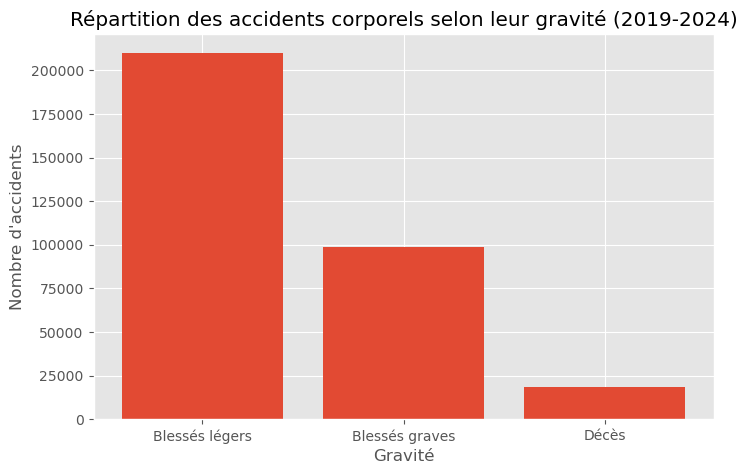

In [166]:
# Tracons le graphique
plt.figure(figsize=(8,5))

plt.bar(gravite.index, gravite.values)

plt.title("Répartition des accidents corporels selon leur gravité (2019-2024)")
plt.xlabel("Gravité")
plt.ylabel("Nombre d'accidents")

plt.show()

**Interprétation** : Cette répartition montre que la majorité des accidents corporels survenus entre 2019 et 2024 se soldent par des blessures légères, qui représentent de loin la catégorie la plus fréquente. Les accidents avec blessés graves arrivent en deuxième position, avec un volume nettement inférieur mais néanmoins important. Les accidents mortels sont les moins nombreux, ce qui est cohérent avec leur caractère exceptionnel par rapport à l'ensemble des accidents corporels. Cette distribution met en évidence un fort déséquilibre entre les niveaux de gravité des accidents. Elle suggère que, si la plupart des accidents n'entraînent pas de décès, un nombre conséquent provoque tout de même des conséquences médicales lourdes. Ces résultats soulignent l'importance de renforcer les actions de prévention afin de réduire non seulement la mortalité routière, mais également les accidents générant des blessures graves, qui représentent un enjeu majeur de santé publique.

In [167]:
# Voyons maintenant l'évolution sur les 6 ans. Pour ce faire, on doit : 
# Calculer le nombre d'accidents par année et par gravité
evolution_gravite = (
    dataset
    .groupby(["annee_fichier", "gravite_accident"])
    .size()
    .unstack(fill_value=0)
)

evolution_gravite

gravite_accident,Blessés graves,Blessés légers,Décès
annee_fichier,,,
2019,17937,37619,3284
2020,14615,30513,2616
2021,16521,36965,3032
2022,16574,35391,3337
2023,16582,35037,3203
2024,16432,34744,3226


**Analyse** : L'évolution annuelle montre une baisse marquée de toutes les catégories d'accidents en 2020, conséquence des restrictions de circulation liées à la pandémie de COVID-19. À partir de 2021, le nombre de blessés graves se stabilise autour de 16 500 cas par an, tandis que les blessés légers diminuent progressivement jusqu'en 2024. En revanche, le nombre de décès reste relativement stable depuis 2021, avec plus de 3 200 victimes par an. Ces résultats suggèrent que, malgré une légère baisse du nombre total d'accidents, la mortalité routière demeure un enjeu majeur.

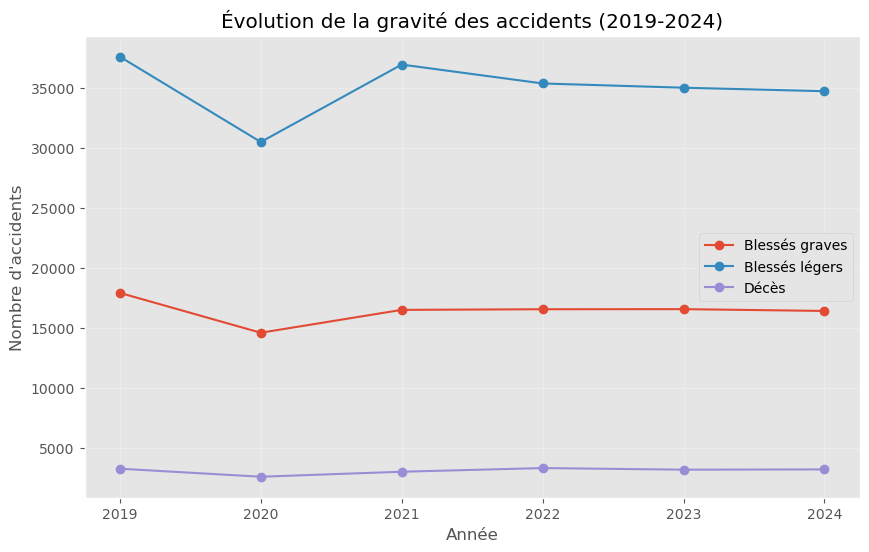

In [168]:
# Tracons l'évolution
plt.figure(figsize=(10,6))

for colonne in evolution_gravite.columns:
    plt.plot(
        evolution_gravite.index.astype(str),
        evolution_gravite[colonne],
        marker="o",
        label=colonne
    )

plt.title("Évolution de la gravité des accidents (2019-2024)")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Interprétation** : Le graphique montre une baisse marquée de toutes les catégories d'accidents en 2020, conséquence probable des restrictions de circulation liées à la pandémie de COVID-19. Dès 2021, le nombre de blessés légers, de blessés graves** et de décès repart à la hausse avec la reprise de la mobilité. Entre 2022 et 2024, les blessés légers diminuent progressivement, tandis que les blessés graves restent globalement stables autour de 16 500 cas par an. Le nombre de décès se stabilise également autour de 3 200 à 3 300 par an. 
Ces résultats indiquent qu'après le choc de 2020, la gravité des accidents est revenue à un niveau relativement stable, sans amélioration significative de la mortalité routière.

**FACTEURS LIES AUX PERSONNES**

**Âge moyen (age_moyen)**

In [171]:
# Créons deux groupes : Accidents mortels et Accidents non mortels
# Puis comparons leur âge moyen.
age_gravite = (
    dataset
    .groupby("gravite_accident")["age_moyen"]
    .mean()
    .round(1)
)

age_gravite

gravite_accident
Blessés graves    40.9
Blessés légers    38.2
Décès             44.9
Name: age_moyen, dtype: float64

**Analyse** : L'analyse montre que l'âge moyen augmente avec la gravité des conséquences de l'accident. Les accidents entraînant des blessés légers concernent des usagers âgés en moyenne de 38,2 ans, contre 40,9 ans pour les blessés graves et 44,9 ans pour les accidents mortels. Ces résultats suggèrent que les usagers les plus âgés sont davantage exposés à des conséquences graves ou fatales en cas d'accident, probablement en raison d'une plus grande vulnérabilité physique.

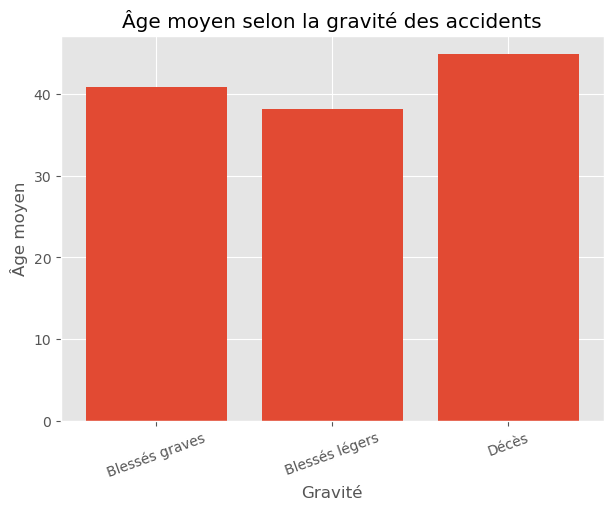

In [172]:
# Représentation graphique 
plt.figure(figsize=(7,5))

plt.bar(
    age_gravite.index,
    age_gravite.values
)

plt.title("Âge moyen selon la gravité des accidents")
plt.xlabel("Gravité")
plt.ylabel("Âge moyen")

plt.xticks(rotation=20)

plt.show()

**Interprétation** : Cette figure met en évidence une relation entre l'âge moyen des usagers impliqués et la gravité des accidents. Les accidents mortels concernent les usagers les plus âgés, avec un âge moyen d'environ 45 ans, contre 41 ans pour les blessés graves et 38 ans pour les blessés légers. Cette progression suggère que la gravité des conséquences d'un accident augmente avec l'âge des victimes. Une plus grande vulnérabilité physique et une capacité de récupération plus limitée chez les personnes âgées peuvent expliquer cette tendance. Toutefois, les écarts restent modérés, ce qui indique que l'âge n'est pas le seul facteur déterminant de la gravité. D'autres variables, telles que la vitesse, le type de véhicule, les conditions de circulation ou le mode de collision, jouent également un rôle important. Cette observation est cohérente avec l'analyse des variables importantes du modèle Random Forest, où l'âge moyen apparaît comme la variable la plus influente. 

**Sexe dominant (sexe_mode)**

In [176]:
# Nous allons maintenant analyser le sexe dominant (sexe_mode) des usagers impliqués dans les accidents, 
# en nous concentrant sur les accidents mortels.

In [177]:
# Vérifions le codage de sexe_mode
dataset["sexe_mode"].value_counts().sort_index()

sexe_mode
-1      4176
 1    232505
 2     90947
Name: count, dtype: int64

In [178]:
# Comparons les accidents selon le sexe dominant
# Comptage
sexe = (
    dataset["sexe_mode"]
    .replace({
        1: "Homme",
        2: "Femme",
        -1: "Non renseigné"
    })
    .value_counts()
    .reset_index()
)

sexe.columns = ["Sexe", "Nombre_accidents"]

sexe

,Sexe,Nombre_accidents
0,Homme,232505
1,Femme,90947
2,Non renseigné,4176


In [179]:
# Nous allons nous limiter aux accidents mortels
mortels = dataset[dataset["gravite_accident"] == "Décès"]

sexe_mortels = (
    mortels["sexe_mode"]
    .replace({
        1: "Homme",
        2: "Femme",
        -1: "Non renseigné"
    })
    .value_counts()
    .reset_index()
)

sexe_mortels.columns = ["Sexe", "Nombre_accidents"]

sexe_mortels

,Sexe,Nombre_accidents
0,Homme,15038
1,Femme,3605
2,Non renseigné,55


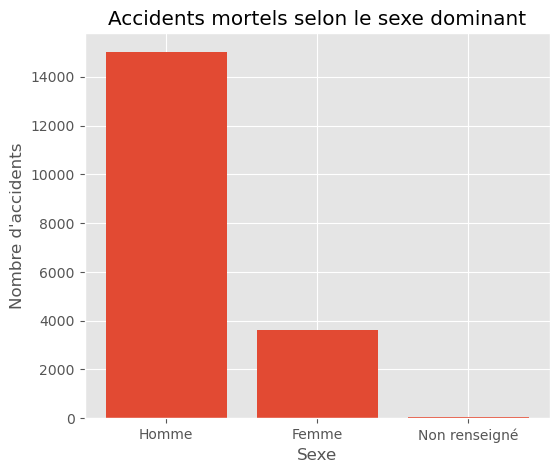

In [180]:
# Visualisation
plt.figure(figsize=(6,5))

plt.bar(
    sexe_mortels["Sexe"],
    sexe_mortels["Nombre_accidents"]
)

plt.title("Accidents mortels selon le sexe dominant")
plt.xlabel("Sexe")
plt.ylabel("Nombre d'accidents")

plt.show()

**Interprétation** : Le graphique montre que les hommes sont très largement majoritaires dans les accidents mortels, avec environ 15 000 accidents, contre environ 3 600 pour les femmes. Les cas non renseignés sont négligeables. Cette forte différence suggère que les hommes sont davantage impliqués dans les accidents les plus graves. Plusieurs facteurs peuvent contribuer à cet écart, notamment une plus grande exposition à la conduite, des distances parcourues plus importantes et des comportements à risque plus fréquents (vitesse excessive, conduite sous l'emprise d'alcool ou de stupéfiants, etc.). 
Ces résultats mettent en évidence l'intérêt de cibler davantage les actions de prévention routière vers les conducteurs masculins, qui apparaissent comme la population la plus exposée aux accidents mortels.

**FACTEURS ENVIRONNEMENTAUX**

In [181]:
# Comparaison
meteo = dataset["atm"].replace({
    -1:"Non renseigné",
    1:"Temps normal",
    2:"Pluie légère",
    3:"Pluie forte",
    4:"Neige",
    5:"Brouillard",
    6:"Vent fort",
    7:"Éblouissant",
    8:"Couvert",
    9:"Autre"
}).value_counts().reset_index()

meteo.columns=["Météo","Nombre_accidents"]

meteo

,Météo,Nombre_accidents
0,Temps normal,258945
1,Pluie légère,36659
2,Couvert,12844
3,Pluie forte,7599
4,Éblouissant,5781
5,Brouillard,2277
6,Autre,1504
7,Neige,1025
8,Vent fort,968
9,Non renseigné,26


**Analyse** : La majorité des accidents (258 945) surviennent par temps normal, ce qui s'explique par le fait que ces conditions météorologiques sont les plus fréquentes. La pluie légère est la deuxième condition la plus représentée (36 659 accidents), suivie dutemps couvert (12 844) et de la pluie forte (7 599). Les accidents sont nettement moins nombreux en cas de brouillard, de neige ou de vent fort, probablement en raison d'une circulation plus faible et d'une plus grande vigilance des usagers. Ces résultats montrent que le volume de trafic influence davantage le nombre d'accidents que les conditions météorologiques elles-mêmes.

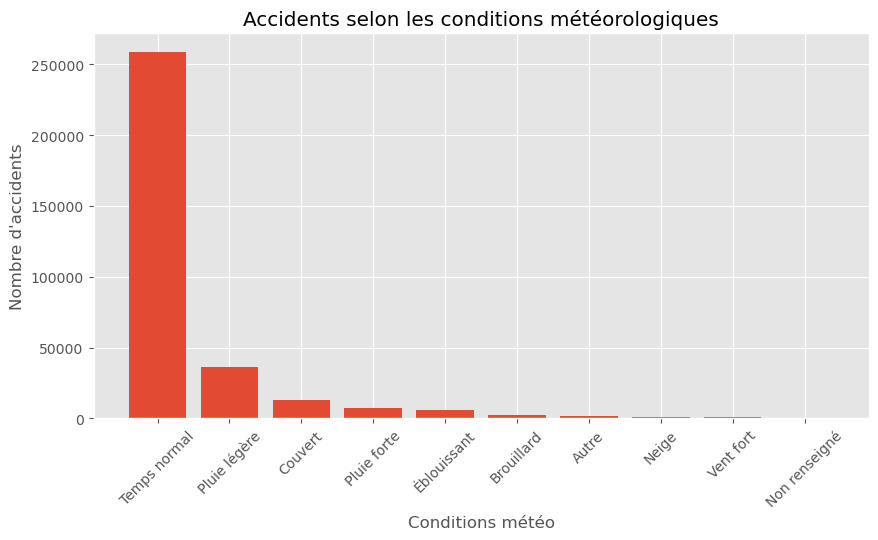

In [182]:
# Tracons le graphique
plt.figure(figsize=(10,5))

plt.bar(
    meteo["Météo"],
    meteo["Nombre_accidents"]
)

plt.xticks(rotation=45)
plt.title("Accidents selon les conditions météorologiques")
plt.xlabel("Conditions météo")
plt.ylabel("Nombre d'accidents")

plt.show()

**Interprétation** : Cette figure montre que la très grande majorité des accidents corporels surviennent par temps normal, ce qui en fait de loin la condition météorologique la plus fréquente. Cette prédominance s'explique principalement par le fait que les conducteurs circulent beaucoup plus souvent sous des conditions météorologiques normales. Les accidents diminuent nettement lorsque les conditions se dégradent, avec la pluie légère en deuxième position, suivie des conditions couvertes et de la pluie forte. Les situations plus exceptionnelles (brouillard, neige, vent fort, verglas, etc.) représentent une faible proportion des accidents. Toutefois, cette faible fréquence ne signifie pas qu'elles sont moins dangereuses, mais plutôt qu'elles sont moins fréquentes. Ainsi, les conditions météorologiques influencent l'occurrence des accidents, mais le volume d'exposition des usagers à chaque type de météo reste un facteur déterminant. Pour évaluer le risque réel associé à chaque condition météorologique, il serait pertinent d'analyser également le taux de gravité des accidents selon la météo.

In [183]:
# Jour / Nuit (lum)
luminosite = dataset["lum"].replace({
    1:"Jour",
    2:"Crépuscule",
    3:"Nuit sans éclairage",
    4:"Nuit éclairage éteint",
    5:"Nuit éclairée"
}).value_counts().reset_index()

luminosite.columns=["Luminosité","Nombre_accidents"]

luminosite

,Luminosité,Nombre_accidents
0,Jour,218409
1,Nuit éclairée,51147
2,Nuit sans éclairage,33324
3,Crépuscule,21529
4,Nuit éclairage éteint,3210
5,-1,9


**Analyse** : L'analyse montre que la majorité des accidents (218 409) se produisent en plein jour, ce qui s'explique par un trafic routier beaucoup plus important durant cette période. Les accidents survenant de nuit, qu'elle soit éclairée (51 147) ou non éclairée (33 324), restent toutefois nombreux et traduisent un risque accru lié à la faible visibilité. Les accidents au crépuscule (21 529) sont également significatifs, cette période étant marquée par des conditions de visibilité changeantes. Ces résultats soulignent que la luminosité, combinée à l'intensité du trafic, influence fortement la survenue des accidents routiers.

In [185]:
# Surface de chaussée (surf)
dataset["surf"].value_counts().sort_index()

surf
-1       121
 1    261783
 2     60779
 3       549
 4       157
 5       507
 6       276
 7      1171
 8       518
 9      1767
Name: count, dtype: int64

In [186]:
surface = dataset["surf"].replace({
    -1:"NR",
    1:"Normale",
    2:"Mouillée",
    3:"Flaques",
    4:"Inondée",
    5:"Enneigée",
    6:"Boue",
    7:"Verglas",
    8:"Corps gras",
    9:"Autre"
}).value_counts().reset_index()

surface.columns=["Surface","Nombre_accidents"]

surface

,Surface,Nombre_accidents
0,Normale,261783
1,Mouillée,60779
2,Autre,1767
3,Verglas,1171
4,Flaques,549
5,Corps gras,518
6,Enneigée,507
7,Boue,276
8,Inondée,157
9,NR,121


**Analyse** : La majorité des accidents (261 783) surviennent sur une chaussée en état normal, ce qui s'explique par le fait que cette situation est la plus fréquente. Les chaussées mouillées représentent néanmoins un nombre important d'accidents (60 779), soulignant l'impact de la pluie sur l'adhérence et les distances de freinage. Les autres états de la chaussée (verglas, neige, boue, flaques, corps gras ou inondation) sont beaucoup plus rares. Ces résultats suggèrent que le volume de circulation est un facteur majeur, tandis que les surfaces dégradées ou glissantes augmentent le risque d'accident lorsqu'elles sont présentes.

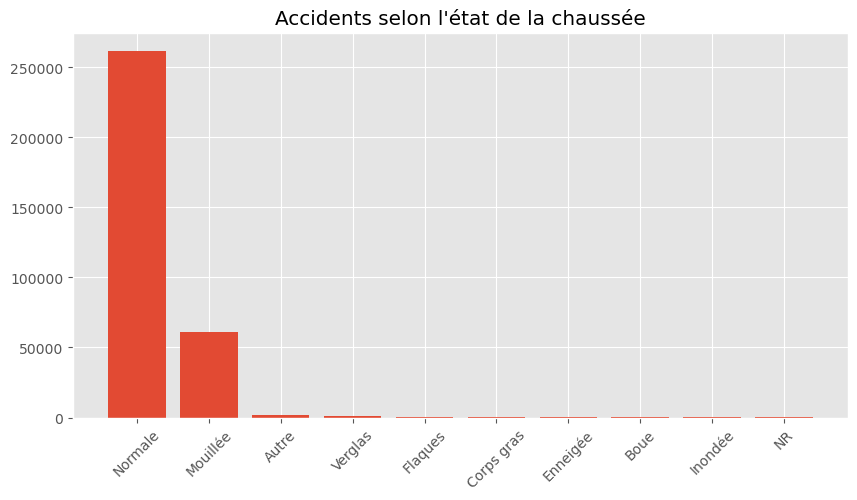

In [187]:
# Graphique
plt.figure(figsize=(10,5))

plt.bar(surface["Surface"],surface["Nombre_accidents"])

plt.xticks(rotation=45)

plt.title("Accidents selon l'état de la chaussée")

plt.show()

**Interprétation** : Ce graphique montre que la très grande majorité des accidents corporels surviennent sur une chaussée en état normal, loin devant toutes les autres conditions de surface. Les chaussées mouillées constituent la deuxième situation la plus fréquente, mais avec un nombre d'accidents très inférieur à celui observé sur chaussée sèche. Les autres états de la chaussée (verglas, flaques, neige, boue, inondation ou corps gras) représentent une part marginale des accidents. Cette répartition s'explique principalement par le fait que les usagers circulent beaucoup plus souvent sur des chaussées sèches que sur des chaussées dégradées ou enneigées. 
Cela ne signifie donc pas qu'une chaussée normale est plus dangereuse, mais qu'elle est la condition de circulation la plus fréquente. Pour évaluer le risque réel associé à chaque état de la chaussée, il serait nécessaire de disposer des données d'exposition (trafic selon les conditions météorologiques et l'état de la chaussée).

In [188]:
# Situation de la route (situ)
dataset["situ"].value_counts().sort_index()

situ
-1       203
 1    272061
 2      2637
 3     23814
 4      6873
 5      7159
 6      3889
 8     10992
Name: count, dtype: int64

In [189]:
# Infrastructure (infra)
dataset["infra"].value_counts().sort_index()

infra
-1      3310
 0    274374
 1      3845
 2      5701
 3      4214
 4      1036
 5     17428
 6      3134
 7       205
 8      2379
 9     12002
Name: count, dtype: int64

In [190]:
# Comparaison spécifique des accidents mortels
mortels = dataset[dataset["gravite_accident"] == "Décès"]

meteo_mortels = (
    mortels["atm"]
    .replace({
        -1:"Non renseigné",
        1:"Temps normal",
        2:"Pluie légère",
        3:"Pluie forte",
        4:"Neige",
        5:"Brouillard",
        6:"Vent fort",
        7:"Éblouissant",
        8:"Couvert",
        9:"Autre"
    })
    .value_counts()
    .reset_index()
)

meteo_mortels.columns = ["Météo", "Nombre_accidents_mortels"]

In [191]:
# Dictionnaire des conditions météo
meteo_dict = {
    -1: "NR",
     1: "Temps normal",
     2: "Pluie légère",
     3: "Pluie forte",
     4: "Neige",
     5: "Brouillard",
     6: "Vent fort",
     7: "Éblouissant",
     8: "Couvert",
     9: "Autre"
}

# Tous les accidents
meteo_total = (
    dataset["atm"]
    .replace(meteo_dict)
    .value_counts()
    .sort_index()
)

# Accidents mortels
meteo_mortels = (
    dataset[dataset["gravite_accident"] == "Décès"]["atm"]
    .replace(meteo_dict)
    .value_counts()
    .sort_index()
)

# Fusion
comparaison = pd.DataFrame({
    "Tous les accidents": meteo_total,
    "Accidents mortels": meteo_mortels
}).fillna(0)

comparaison

,Tous les accidents,Accidents mortels
atm,,
Autre,1504,147
Brouillard,2277,295
Couvert,12844,843
NR,26,6
Neige,1025,75
Pluie forte,7599,476
Pluie légère,36659,1790
Temps normal,258945,14514
Vent fort,968,102


**Analyse** : Les accidents mortels surviennent majoritairement par temps normal (14 514 décès), ce qui reflète la prédominance de ces conditions météorologiques dans la circulation quotidienne. Toutefois, des conditions telles que le brouillard, la pluie forte ou le vent fort restent associées à un nombre non négligeable d'accidents mortels malgré leur faible fréquence. La pluie légère est également impliquée dans un nombre important de décès (1 790). Ces résultats suggèrent que si le volume de trafic explique la majorité des accidents mortels, les conditions météorologiques dégradées peuvent accroître la gravité des accidents lorsqu'elles surviennent.

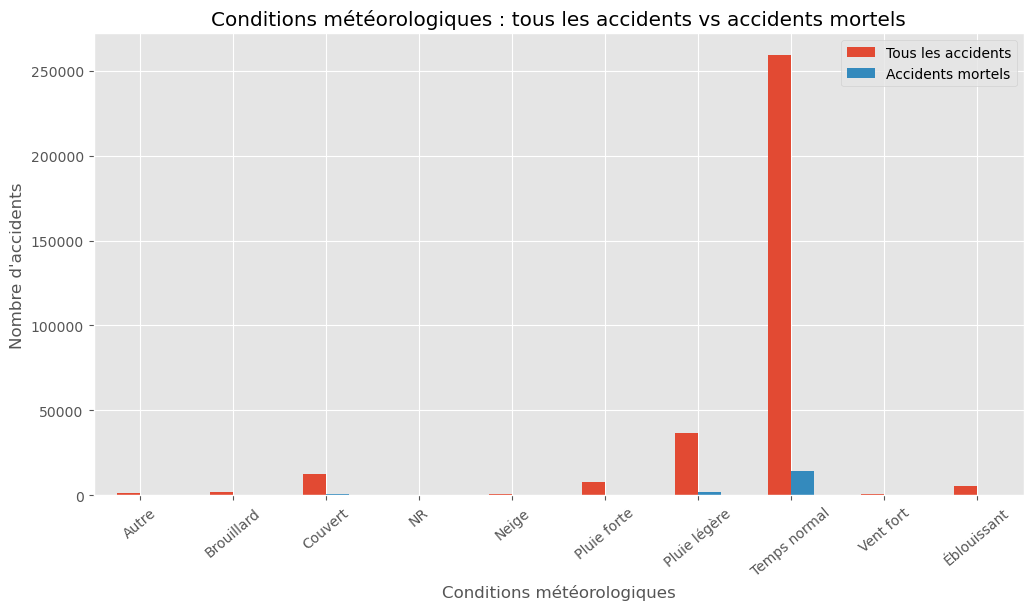

In [260]:
# Graphique comparatif
comparaison.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Conditions météorologiques : tous les accidents vs accidents mortels")
plt.xlabel("Conditions météorologiques")
plt.ylabel("Nombre d'accidents")

plt.xticks(rotation=40)
plt.legend()

plt.show()

**Interprétation** : Le graphique montre que la très grande majorité des accidents, y compris des accidents mortels, surviennent par temps normal. Cela s'explique principalement par le fait que ces conditions météorologiques sont les plus fréquentes et correspondent aux périodes où le trafic est le plus important. La pluie légère constitue la deuxième condition la plus représentée, suivie du temps couvert et de la pluie forte. Les accidents sont beaucoup plus rares en cas de brouillard, de neige ou de vent fort. Toutefois, la présence d'accidents mortels dans toutes les conditions météorologiques indique que le risque de décès ne disparaît jamais, même lorsque les conditions semblent favorables. 
Ces résultats suggèrent que les comportements des usagers (vitesse, vigilance, alcool, etc.) jouent probablement un rôle au moins aussi important que la météo dans la gravité des accidents.

**TYPE DE ROUTE**

**Catégorie de route (catr)**

In [193]:
# Décodons les catégories
route_dict = {
    1: "Autoroute",
    2: "Route nationale",
    3: "Route départementale",
    4: "Voie communale",
    5: "Hors réseau public",
    6: "Parking",
    7: "Métropole urbaine",
    9: "Autre"
}

dataset["type_route"] = dataset["catr"].replace(route_dict)

In [194]:
# Vérification
dataset["type_route"].value_counts()

type_route
Voie communale          138248
Route départementale    122714
Autoroute                30949
Route nationale          21134
Métropole urbaine         9797
Parking                   2412
Autre                     1977
Hors réseau public         397
Name: count, dtype: int64

In [195]:
# Nombre d'accidents par type de route
acc_route = (
    dataset["type_route"]
    .value_counts()
    .reset_index()
)

acc_route.columns = [
    "Type_route",
    "Nombre_accidents"
]

acc_route

,Type_route,Nombre_accidents
0,Voie communale,138248
1,Route départementale,122714
2,Autoroute,30949
3,Route nationale,21134
4,Métropole urbaine,9797
5,Parking,2412
6,Autre,1977
7,Hors réseau public,397


**Analyse** : Les voies communales concentrent le plus grand nombre d'accidents (138 248), suivies des routes départementales (122 714), ce qui reflète leur forte fréquentation. Les autoroutes et routes nationales enregistrent un nombre d'accidents nettement inférieur malgré un trafic important. Les accidents sont beaucoup plus rares sur les parkings, les métropoles urbaines, les hors réseau public et les autres types de voies. 
Ces résultats montrent que les axes du réseau routier local constituent les principaux lieux de survenue des accidents et doivent être au cœur des actions de prévention.

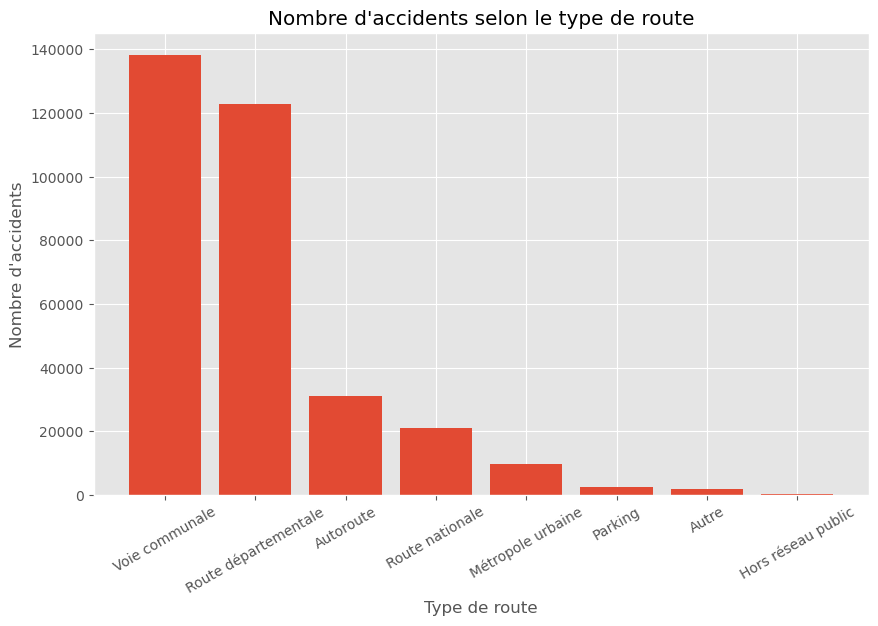

In [196]:
# Graphique
plt.figure(figsize=(10,6))

plt.bar(
    acc_route["Type_route"],
    acc_route["Nombre_accidents"]
)

plt.title("Nombre d'accidents selon le type de route")
plt.xlabel("Type de route")
plt.ylabel("Nombre d'accidents")

plt.xticks(rotation=30)

plt.show()

**Interprétation** : Cette figure montre que les accidents corporels se concentrent principalement sur les voies communales et les routes départementales, qui représentent de loin les catégories de routes les plus accidentogènes sur la période 2019-2024. Les autoroutes et les routes nationales enregistrent un nombre d'accidents nettement inférieur malgré un trafic souvent important. Les métropoles urbaines arrivent ensuite avec un volume d'accidents plus modéré. Les accidents sur les parkings, les routes classées autres et le hors réseau public restent marginaux. Cette répartition suggère que le risque d'accident est plus élevé sur les axes du quotidien, où les déplacements sont les plus fréquents et les interactions entre usagers plus nombreuses. 
Cette figure met ainsi en évidence que les efforts de prévention et d'aménagement devraient cibler en priorité les voies communales et départementales, qui concentrent la majorité des accidents corporels en France.

**Agglomération / Hors agglomération**

In [197]:
agg_dict = {
    1: "Hors agglomération",
    2: "En agglomération"
}

dataset["zone"] = dataset["agg"].replace(agg_dict)

In [198]:
acc_zone = (
    dataset["zone"]
    .value_counts()
    .reset_index()
)

acc_zone.columns = [
    "Zone",
    "Nombre_accidents"
]

acc_zone

,Zone,Nombre_accidents
0,En agglomération,208478
1,Hors agglomération,119150


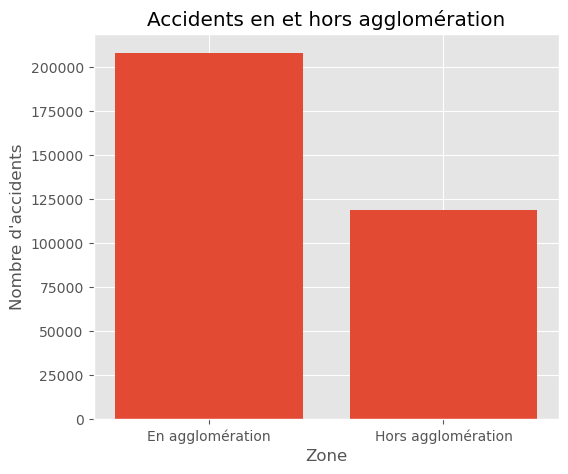

In [199]:
plt.figure(figsize=(6,5))

plt.bar(
    acc_zone["Zone"],
    acc_zone["Nombre_accidents"]
)

plt.title("Accidents en et hors agglomération")
plt.xlabel("Zone")
plt.ylabel("Nombre d'accidents")

plt.show()

**Interprétation** : Le graphique montre que les accidents se produisent majoritairement en agglomération, avec environ 208 000 accidents, contre 119 000 hors agglomération sur la période 2019–2024. Cette différence s'explique par une circulation plus dense, un nombre plus élevé d'usagers et de nombreuses interactions entre véhicules, piétons et cyclistes en milieu urbain. En revanche, un nombre plus élevé d'accidents ne signifie pas nécessairement une plus grande gravité. En effet, les accidents survenant hors agglomération sont souvent plus sévères en raison de vitesses de circulation plus élevées. 
Ces résultats soulignent la nécessité d'adapter les politiques de sécurité routière aux spécificités des zones urbaines et rurales.

**Remarque** : Comme pour la météo, il est pertinent de comparer les accidents mortels selon le type de route.

In [200]:
mortels_route = (
    dataset[dataset["gravite_accident"] == "Décès"]["type_route"]
    .value_counts()
)

comparaison_route = pd.DataFrame({
    "Tous les accidents": dataset["type_route"].value_counts(),
    "Accidents mortels": mortels_route
}).fillna(0)

comparaison_route

,Tous les accidents,Accidents mortels
type_route,,
Autoroute,30949,1414
Autre,1977,123
Hors réseau public,397,33
Métropole urbaine,9797,496
Parking,2412,118
Route départementale,122714,10863
Route nationale,21134,1854
Voie communale,138248,3797


**Analyse** : Les voies communales concentrent le plus grand nombre d'accidents (138 248), mais les routes départementales enregistrent le plus grand nombre d'accidents mortels (10 863), ce qui en fait les axes les plus meurtriers. Les routes nationales arrivent ensuite avec 1 854 accidents mortels, tandis que les autoroutes, malgré un trafic important, comptabilisent seulement 1 414 accidents mortels. Les parkings, métropoles urbaines et autres types de voies présentent des effectifs nettement plus faibles. 
Ces résultats suggèrent que les routes départementales constituent une priorité en matière de prévention et d'aménagement pour améliorer la sécurité routière.

# Graphique
comparaison_route.plot(
    kind="bar",
    figsize=(11,6)
)

plt.title("Type de route : tous les accidents vs accidents mortels")
plt.xlabel("Type de route")
plt.ylabel("Nombre d'accidents")

plt.xticks(rotation=30)

plt.show()

**TYPE DE VEHICULE**

In [202]:
# Créons les libellés des véhicules
vehicules = {
    1: "Bicyclette",
    2: "Cyclomoteur",
    3: "Voiturette",
    7: "Voiture",
    10: "Utilitaire",
    13: "Poids lourd",
    14: "Poids lourd",
    15: "Autocar",
    16: "Tracteur",
    17: "Tramway",
    20: "Engin spécial",
    21: "Tracteur agricole",
    30: "Scooter <50cc",
    31: "Moto 50-125cc",
    32: "Moto >125cc",
    33: "Moto lourde",
    34: "Quad",
    35: "Train",
    36: "Bus",
    37: "Autobus",
    38: "Autocar",
    39: "Train",
    40: "Tramway",
    41: "Trottinette",
    42: "Gyropode",
    43: "EDPM",
    50: "Vélo",
    60: "Piéton",
    80: "Animal",
    99: "Autre"
}

dataset["type_vehicule"] = dataset["catv_mode"].map(vehicules)

In [204]:
# Vérification
dataset["type_vehicule"].value_counts().head(15)

type_vehicule
Voiture          214994
Bicyclette        29461
Cyclomoteur       19472
Utilitaire        18867
Moto lourde       13614
Scooter <50cc      5898
Moto >125cc        3357
Moto 50-125cc      2901
Voiturette         2677
Vélo               2519
Poids lourd        2160
Autocar            1596
Quad               1454
Autobus            1449
Tramway            1232
Name: count, dtype: int64

In [205]:
# Nombre total d'accidents par type de véhicule
veh = (
    dataset["type_vehicule"]
    .value_counts()
    .head(10)
    .reset_index()
)

veh.columns = ["Type", "Nombre"]

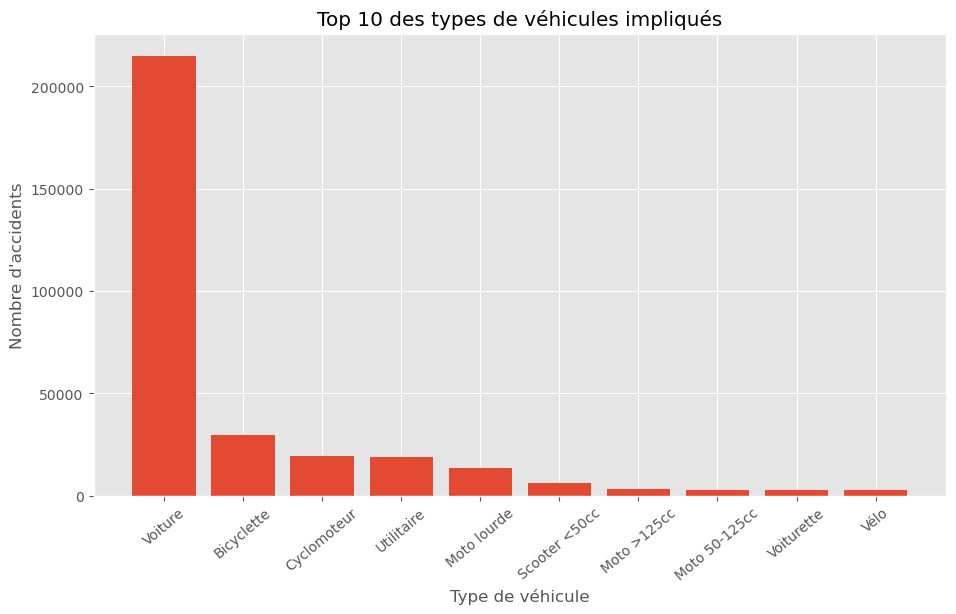

In [206]:
# Graphique
plt.figure(figsize=(11,6))

plt.bar(
    veh["Type"],
    veh["Nombre"]
)

plt.title("Top 10 des types de véhicules impliqués")
plt.xlabel("Type de véhicule")
plt.ylabel("Nombre d'accidents")

plt.xticks(rotation=40)

plt.show()

**Interprétation** : Ce graphique montre que les voitures sont de très loin le type de véhicule le plus impliqué dans les accidents mortels sur la période 2019–2024. Cette prédominance s'explique notamment par leur forte présence dans le parc automobile français et leur utilisation quotidienne. Les motos lourdes, les véhicules utilitaires et les bicyclettes constituent le deuxième groupe de véhicules les plus concernés, mais avec des effectifs très inférieurs à ceux des voitures. Les cyclomoteurs et les poids lourds sont également impliqués, dans une moindre mesure. Les autocars, tramways, motos 50–125 cc et tracteurs agricoles représentent les catégories les moins fréquentes. 
Ces résultats montrent que les actions de prévention doivent prioritairement cibler les automobilistes, tout en renforçant la sécurité des usagers vulnérables, notamment les motocyclistes et les cyclistes.

In [207]:
# Comparaison spécifique des accidents mortels
mortels = dataset[dataset["gravite_accident"] == "Décès"]

veh_mortels = (
    mortels["type_vehicule"]
    .value_counts()
    .head(10)
    .reset_index()
)

veh_mortels.columns = ["Type", "Nombre"]

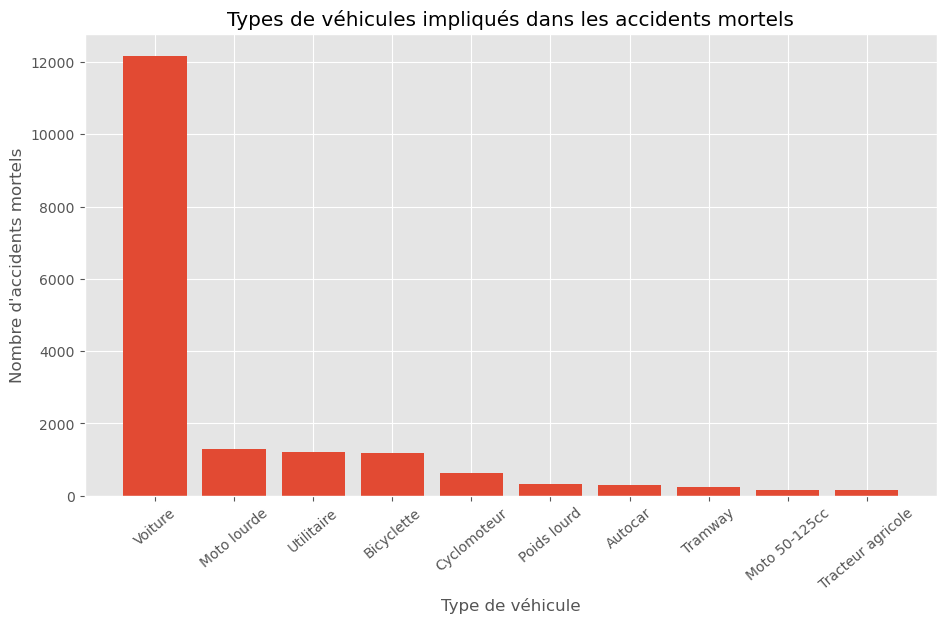

In [208]:
# Graphique
plt.figure(figsize=(11,6))

plt.bar(
    veh_mortels["Type"],
    veh_mortels["Nombre"]
)

plt.title("Types de véhicules impliqués dans les accidents mortels")
plt.xlabel("Type de véhicule")
plt.ylabel("Nombre d'accidents mortels")

plt.xticks(rotation=40)

plt.show()

**Remarque** : Il est important de préciser une **limite méthodologique** a cette analyse. Comme nous avons agrégé les données véhicules en conservant le type de véhicule dominant (catv_mode) pour chaque accident, cette analyse décrit plutôt le type principal de véhicule associé à l'accident et non l'ensemble des véhicules impliqués. 
Pour analyser précisément la responsabilité ou l'implication de chaque catégorie de véhicule (voiture, moto, vélo, poids lourd, etc.), il faudrait travailler directement sur la table vehicules sans agrégation.

**Interprétation** : Cette figure met en évidence une très forte prédominance des voitures dans les accidents mortels entre 2019 et 2024. Elles sont impliquées dans plus de 12 000 accidents mortels, très loin devant tous les autres types de véhicules. Les motos lourdes, utilitaires et bicyclettes arrivent ensuite, avec des effectifs comparables mais nettement inférieurs. Les cyclomoteurs occupent une position intermédiaire, tandis que les poids lourds, autocars, tramways, motos de 50–125 cm³ et tracteurs agricoles sont beaucoup moins représentés. Cette répartition reflète en partie l'importance du parc automobile français et la fréquence d'utilisation des voitures sur le réseau routier. Toutefois, elle ne permet pas à elle seule d'évaluer le niveau de risque propre à chaque type de véhicule, puisqu'elle ne tient pas compte de leur exposition au trafic. 
Globalement, les voitures constituent le principal enjeu de sécurité routière, tandis que les deux-roues motorisés restent également des catégories à surveiller en raison de leur implication non négligeable dans les accidents mortels.

**ANALYSE COVID 19**

Cette partie apporte une réelle valeur ajoutée au projet, car elle répond à une question d'actualité tout en mobilisant des analyses temporelles. Nous allons procéder étape par étape.

In [209]:
# Évolution annuelle des accidents
accidents_annee = (
    dataset.groupby("an")
    .size()
    .reset_index(name="Nombre_accidents")
)

accidents_annee

,an,Nombre_accidents
0,2019,58840
1,2020,47744
2,2021,56518
3,2022,55302
4,2023,54822
5,2024,54402


**Analyse** : Le nombre d'accidents routiers diminue globalement entre 2019 (58 840) et 2024 (54 402), malgré un net rebond après la forte baisse observée en 2020 (47 744), liée aux confinements durant la pandémie de COVID-19. À partir de 2021, les accidents augmentent avec la reprise de la mobilité, puis diminuent légèrement entre 2022 et 2024. 
Cette tendance traduit un retour progressif à un niveau de circulation proche de celui d'avant la pandémie, tout en restant légèrement inférieur à celui de 2019.

In [210]:
# Évolution annuelle des accidents mortels
deces_annee = (
    dataset[dataset["gravite_accident"] == "Décès"]
    .groupby("an")
    .size()
    .reset_index(name="Accidents_mortels")
)

deces_annee

,an,Accidents_mortels
0,2019,3284
1,2020,2616
2,2021,3032
3,2022,3337
4,2023,3203
5,2024,3226


**Analyse** : Le nombre d'accidents mortels diminue fortement entre 2019 (3 284) et 2020 (2 616), ce qui coïncide avec les restrictions de déplacement liées à la pandémie de COVID-19. À partir de 2021, la mortalité routière repart à la hausse avec le retour progressif du trafic. En 2022, elle atteint son niveau le plus élevé de la période (3 337 accidents mortels). 
Les années 2023 et 2024 montrent ensuite une légère stabilisation autour de 3 200 accidents mortels, indiquant que la baisse du nombre total d'accidents ne s'est pas traduite par une diminution durable de la mortalité routière.

In [211]:
# Fusion des deux tableaux
covid = accidents_annee.merge(
    deces_annee,
    on="an",
    how="left"
)

covid["Accidents_mortels"] = covid["Accidents_mortels"].fillna(0).astype(int)

covid

,an,Nombre_accidents,Accidents_mortels
0,2019,58840,3284
1,2020,47744,2616
2,2021,56518,3032
3,2022,55302,3337
4,2023,54822,3203
5,2024,54402,3226


**Analyse** : Le nombre total d'accidents diminue de 58 840 en 2019 à 54 402 en 2024, avec une baisse particulièrement marquée en 2020 en raison de la pandémie de COVID-19. Les accidents mortels suivent une évolution similaire en 2020, avant de remonter dès 2021. Entre 2022 et 2024, le nombre de décès reste relativement stable, autour de 3 200 accidents mortels par an, malgré la légère diminution du nombre total d'accidents. 
Ces résultats suggèrent que la réduction du volume d'accidents ne se traduit pas automatiquement par une baisse proportionnelle de la mortalité routière.

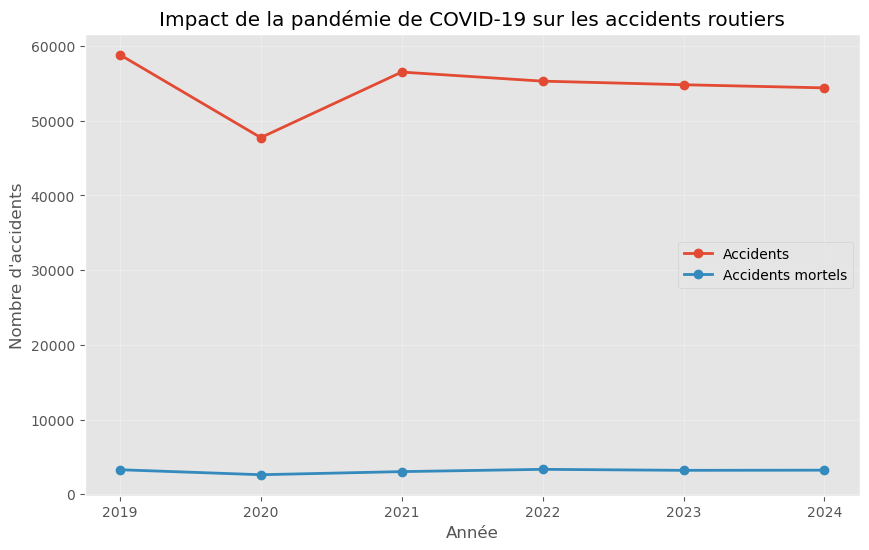

In [212]:
# Graphique comparatif
plt.figure(figsize=(10,6))

plt.plot(
    covid["an"],
    covid["Nombre_accidents"],
    marker="o",
    linewidth=2,
    label="Accidents"
)

plt.plot(
    covid["an"],
    covid["Accidents_mortels"],
    marker="o",
    linewidth=2,
    label="Accidents mortels"
)

plt.title("Impact de la pandémie de COVID-19 sur les accidents routiers")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")

plt.xticks(covid["an"])

plt.grid(alpha=0.3)

plt.legend()

plt.show()

**Interprétation** : Ce graphique met clairement en évidence l'impact de la pandémie de COVID-19 sur l'accidentalité routière en France. En 2020, le nombre total d'accidents chute fortement par rapport à 2019, passant d'environ 58 800 à 47 700 accidents, ce qui coïncide avec les périodes de confinement et la forte réduction des déplacements. À partir de 2021, le nombre d'accidents repart à la hausse avec la reprise de la mobilité, sans toutefois retrouver le niveau observé avant la pandémie. Entre 2022 et 2024, une légère diminution progressive des accidents est observée, traduisant une relative stabilisation de l'accidentalité. Les accidents mortels suivent une évolution différente : ils diminuent également en 2020, mais augmentent de nouveau dès 2021 et atteignent un niveau supérieur à celui de 2019 en 2022. Malgré une légère baisse en 2023, ils restent globalement stables en 2024. 
Ces résultats montrent que la baisse du trafic durant la pandémie a réduit le nombre d'accidents, mais que la reprise de la circulation s'est accompagnée d'un retour durable de la mortalité routière à un niveau élevé.

In [213]:
# Quantifions l'effet du confinement
covid["Variation_accidents_%"] = (
    covid["Nombre_accidents"]
    .pct_change() * 100
).round(1)

covid["Variation_mortels_%"] = (
    covid["Accidents_mortels"]
    .pct_change() * 100
).round(1)

covid

,an,Nombre_accidents,Accidents_mortels,Variation_accidents_%,Variation_mortels_%
0,2019,58840,3284,NaN,NaN
1,2020,47744,2616,-18.9,-20.3
2,2021,56518,3032,18.4,15.9
3,2022,55302,3337,-2.2,10.1
4,2023,54822,3203,-0.9,-4.0
5,2024,54402,3226,-0.8,0.7


**Analyse** : L'année 2020 se distingue par une forte baisse des accidents (-18,9 %) et des accidents mortels (-20,3 %), conséquence probable des confinements liés à la pandémie de COVID-19. En 2021, la reprise de la circulation s'accompagne d'une hausse des accidents (+18,4 %) et des décès (+15,9 %). Entre 2022 et 2024, le nombre total d'accidents diminue légèrement, tandis que le nombre d'accidents mortels reste relativement stable, avec une légère hausse en 2024 (+0,7 %). 
Ces résultats montrent que la baisse du nombre d'accidents ne s'accompagne pas nécessairement d'une diminution de la mortalité routière.

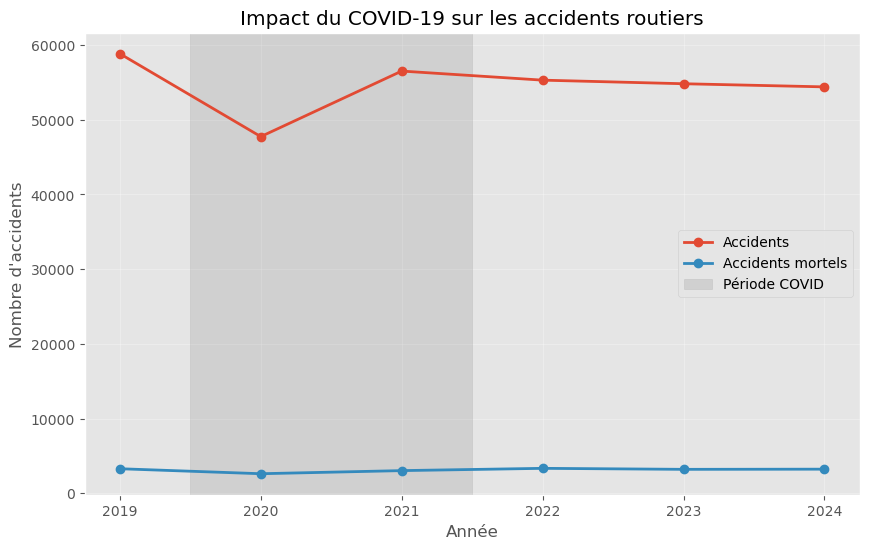

In [214]:
# Mettons en évidence la période COVID
plt.figure(figsize=(10,6))

plt.plot(
    covid["an"],
    covid["Nombre_accidents"],
    marker="o",
    linewidth=2,
    label="Accidents"
)

plt.plot(
    covid["an"],
    covid["Accidents_mortels"],
    marker="o",
    linewidth=2,
    label="Accidents mortels"
)

# Mise en évidence de la période COVID
plt.axvspan(2019.5, 2021.5, alpha=0.2, color="gray", label="Période COVID")

plt.title("Impact du COVID-19 sur les accidents routiers")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")

plt.xticks(covid["an"])

plt.legend()

plt.grid(alpha=0.3)

plt.show()

**Interprétation** : Cette figure met clairement en évidence l'impact de la pandémie de COVID-19 sur l'accidentalité routière en France. En 2020, année marquée par les confinements et les fortes restrictions de déplacement, le nombre total d'accidents chute fortement par rapport à 2019. Les accidents mortels diminuent également durant cette période, mais dans une moindre proportion que l'ensemble des accidents. Dès 2021, avec la reprise progressive des déplacements, le nombre d'accidents remonte nettement pour se rapprocher du niveau d'avant la crise sanitaire. À partir de 2022, les deux indicateurs se stabilisent, avec une légère baisse des accidents corporels mais un nombre d'accidents mortels relativement stable autour de 3 200 à 3 300 cas par an. 
Elle montre que le COVID-19 a eu un effet temporaire et significatif sur la réduction des accidents, principalement en raison de la diminution du trafic routier. Une fois les restrictions levées, l'accidentalité est rapidement revenue à un niveau proche de celui observé avant la pandémie.

**CORRELATIONS**

In [215]:
# Sélection des variables numériques
corr = dataset.select_dtypes(include=["int64", "float64"])

corr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327628 entries, 0 to 327627
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Num_Acc                  327628 non-null  int64  
 1   jour                     327628 non-null  int64  
 2   mois                     327628 non-null  int64  
 3   an                       327628 non-null  int64  
 4   lum                      327628 non-null  int64  
 5   agg                      327628 non-null  int64  
 6   int                      327628 non-null  int64  
 7   atm                      327628 non-null  int64  
 8   col                      327628 non-null  int64  
 9   lat                      327628 non-null  float64
 10  long                     327628 non-null  float64
 11  annee_fichier            327628 non-null  int64  
 12  catr                     327628 non-null  int64  
 13  circ                     327628 non-null  int64  
 14  nbv 

In [216]:
# Calculons la matrice de corrélation
matrice_corr = corr.corr(numeric_only=True)

matrice_corr.round(2)

,Num_Acc,jour,mois,an,lum,agg,int,atm,col,lat,long,annee_fichier,catr,circ,nbv,vma,surf,infra,situ,nb_vehicules,catv_mode,choc_mode,manv_mode,motor_mode,nb_usagers,grav_max,nb_tues,nb_blesses_hospitalises,nb_blesses_legers,age_moyen,sexe_mode,catu_mode
Num_Acc,1.00,-0.01,-0.01,1.00,0.00,-0.02,0.01,0.01,-0.01,-0.01,-0.03,1.00,-0.00,-0.03,-0.08,-0.05,0.00,-0.01,0.05,-0.00,0.01,-0.01,-0.03,0.05,0.02,-0.00,0.01,-0.00,0.00,0.01,-0.03,0.01
jour,-0.01,1.00,-0.01,-0.01,-0.01,-0.01,0.00,-0.01,0.00,0.00,-0.00,-0.01,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00
mois,-0.01,-0.01,1.00,-0.01,0.06,-0.01,0.00,0.03,-0.01,0.00,-0.00,-0.01,-0.01,-0.00,-0.00,0.01,0.02,-0.00,0.00,0.01,-0.01,-0.00,-0.01,0.00,0.01,-0.00,0.00,0.00,0.00,-0.01,0.00,-0.01
an,1.00,-0.01,-0.01,1.00,0.00,-0.02,0.01,0.01,-0.01,-0.01,-0.03,1.00,-0.00,-0.03,-0.08,-0.05,0.00,-0.01,0.05,-0.00,0.01,-0.01,-0.03,0.05,0.02,-0.00,0.01,-0.00,0.00,0.01,-0.03,0.01
lum,0.00,-0.01,0.06,0.00,1.00,0.10,0.02,0.01,0.05,-0.01,-0.02,0.00,0.03,0.00,0.03,-0.06,0.06,0.02,0.02,-0.07,0.01,-0.03,0.01,-0.03,-0.01,0.02,0.01,-0.01,0.03,-0.18,-0.07,0.03
agg,-0.02,-0.01,-0.01,-0.02,0.10,1.00,0.18,-0.02,-0.00,0.03,0.02,-0.02,0.48,-0.14,-0.17,-0.66,-0.07,0.07,-0.04,-0.08,-0.00,-0.10,0.08,0.05,-0.08,0.19,-0.15,-0.21,0.04,-0.00,0.01,0.12
int,0.01,0.00,0.00,0.01,0.02,0.18,1.00,0.01,-0.06,-0.00,0.00,0.01,0.13,-0.09,-0.08,-0.19,-0.02,0.19,0.03,0.02,-0.03,-0.05,0.05,0.00,-0.01,0.05,-0.05,-0.05,0.01,0.03,0.01,-0.00
atm,0.01,-0.01,0.03,0.01,0.01,-0.02,0.01,1.00,0.03,0.05,0.00,0.01,-0.00,0.02,-0.01,0.01,0.21,0.02,0.02,-0.04,-0.01,0.01,-0.00,0.00,-0.01,-0.02,0.02,0.02,-0.01,0.02,0.02,0.02
col,-0.01,0.00,-0.01,-0.01,0.05,-0.00,-0.06,0.03,1.00,0.01,0.02,-0.01,0.04,-0.04,-0.07,-0.03,0.09,0.03,0.24,-0.59,0.31,0.20,0.24,0.16,-0.25,-0.14,0.05,0.04,-0.14,0.02,0.03,0.31
lat,-0.01,0.00,0.00,-0.01,-0.01,0.03,-0.00,0.05,0.01,1.00,-0.12,-0.01,0.04,0.00,0.06,0.01,0.03,-0.02,-0.00,0.01,0.00,0.01,-0.02,0.02,-0.02,0.05,-0.03,-0.05,0.02,0.02,0.00,-0.01


**Analyse** : La matrice de corrélation montre que la plupart des variables présentent des corrélations faibles, ce qui indique une faible dépendance linéaire entre elles. Les corrélations les plus marquées concernent grav_max avec le nombre de blessés légers (0,65) et, dans le sens inverse, avec le nombre de tués (-0,50) et les blessés hospitalisés (-0,52). On observe également une forte corrélation négative entre l'agglomération (agg) et la vitesse maximale autorisée (vma) (-0,66), les vitesses étant généralement plus faibles en agglomération. 
Enfin, le nombre de véhicules est positivement corrélé au nombre d'usagers (0,53), ce qui est cohérent avec la dynamique des accidents impliquant plusieurs personnes.

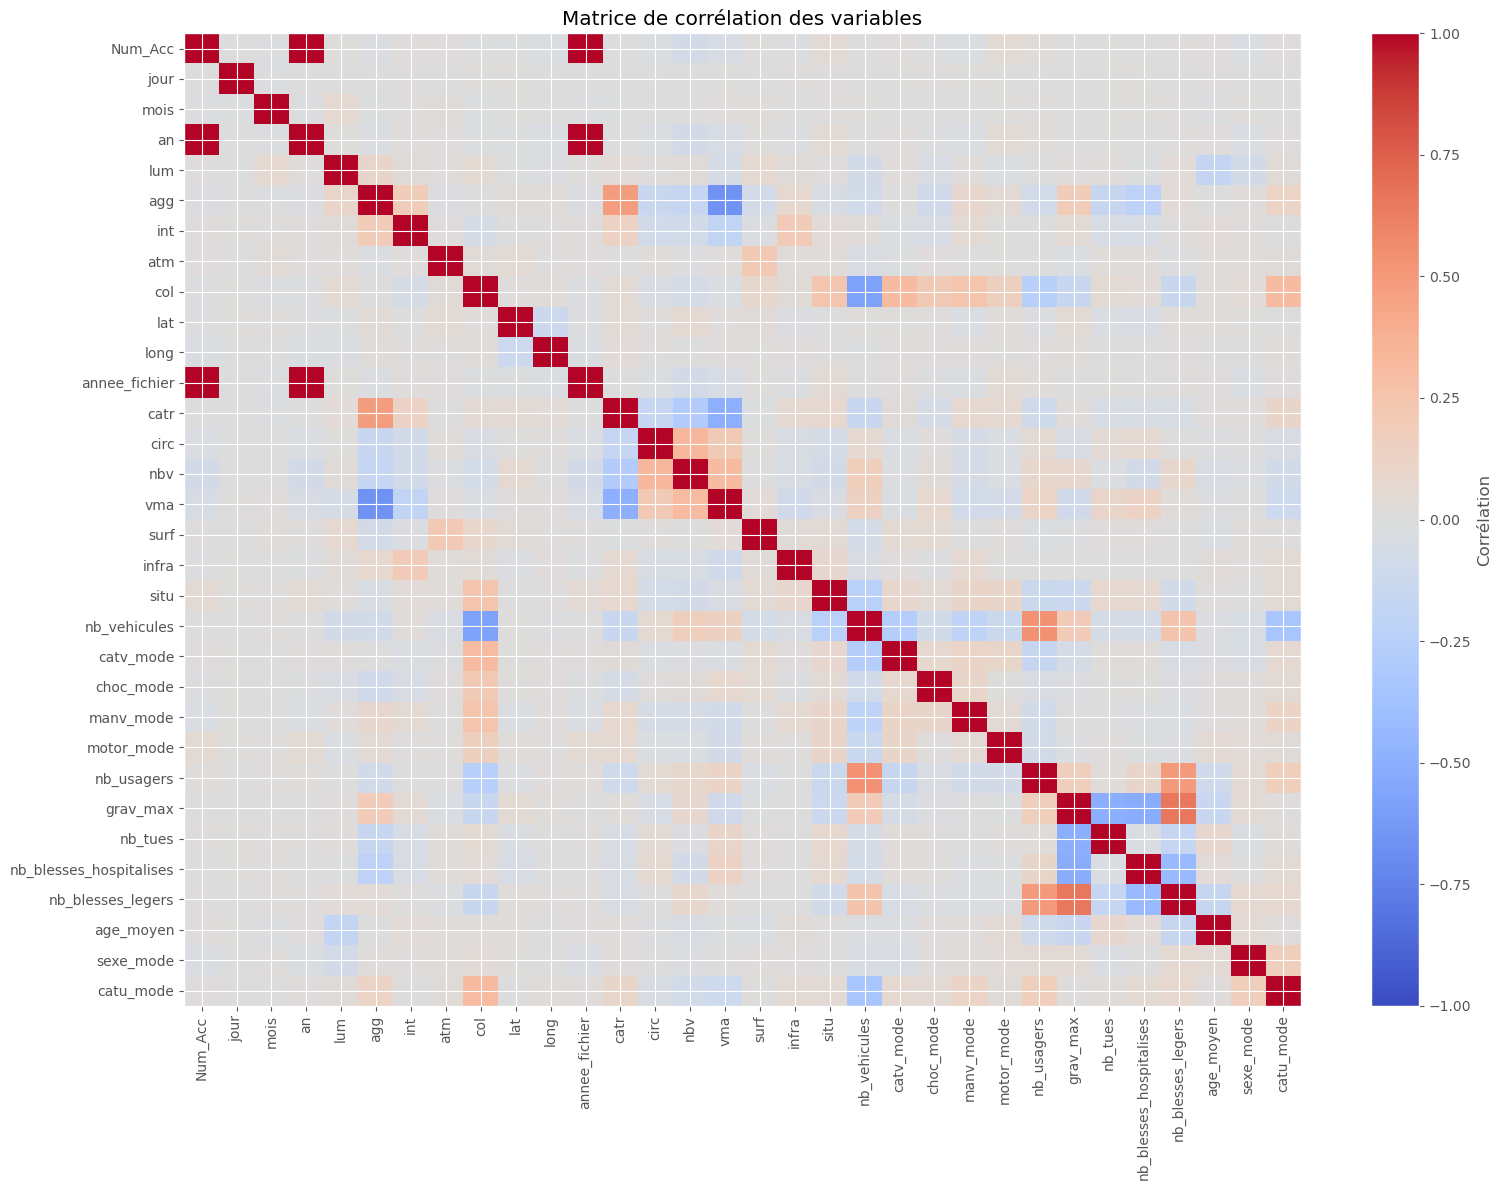

In [217]:
# Affichons la Heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))

plt.imshow(
    matrice_corr,
    cmap="coolwarm",
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Corrélation")

plt.xticks(
    range(len(matrice_corr.columns)),
    matrice_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(matrice_corr.columns)),
    matrice_corr.columns
)

plt.title("Matrice de corrélation des variables")

plt.tight_layout()

plt.show()

**Interprétation** : Cette matrice de corrélation met en évidence les relations linéaires entre les différentes variables du jeu de données. La diagonale rouge foncé correspond à une corrélation parfaite (1), chaque variable étant parfaitement corrélée avec elle-même. La majorité des cases sont de couleur claire, indiquant des corrélations faibles ou proches de zéro entre les variables. Quelques corrélations positives modérées apparaissent, notamment entre le nombre d'usagers et le nombre de véhicules, ou encore entre certaines variables décrivant les caractéristiques de l'accident. Des corrélations négatives sont également observées, par exemple entre la vitesse maximale autorisée (vma) et certaines caractéristiques de la route. L'absence de corrélations très fortes entre la plupart des variables suggère une faible multicolinéarité, ce qui est favorable à la construction des modèles prédictifs. 
Globalement, les variables apportent des informations relativement complémentaires pour expliquer les accidents routiers.

In [218]:
# variables les plus liées à la gravité
corr_gravite = (
    matrice_corr["grav_max"]
    .sort_values(ascending=False)
)

corr_gravite

grav_max                   1.000000
nb_blesses_legers          0.650026
nb_vehicules               0.187914
agg                        0.185353
nb_usagers                 0.170709
nbv                        0.085653
lat                        0.048273
int                        0.045386
sexe_mode                  0.044712
catr                       0.020582
long                       0.017587
lum                        0.015349
catu_mode                  0.007249
Num_Acc                   -0.002526
annee_fichier             -0.002527
an                        -0.002527
jour                      -0.003045
mois                      -0.004815
infra                     -0.005254
manv_mode                 -0.007140
motor_mode                -0.012000
surf                      -0.015469
choc_mode                 -0.019884
atm                       -0.023589
circ                      -0.051269
catv_mode                 -0.059242
vma                       -0.096116
situ                      -0

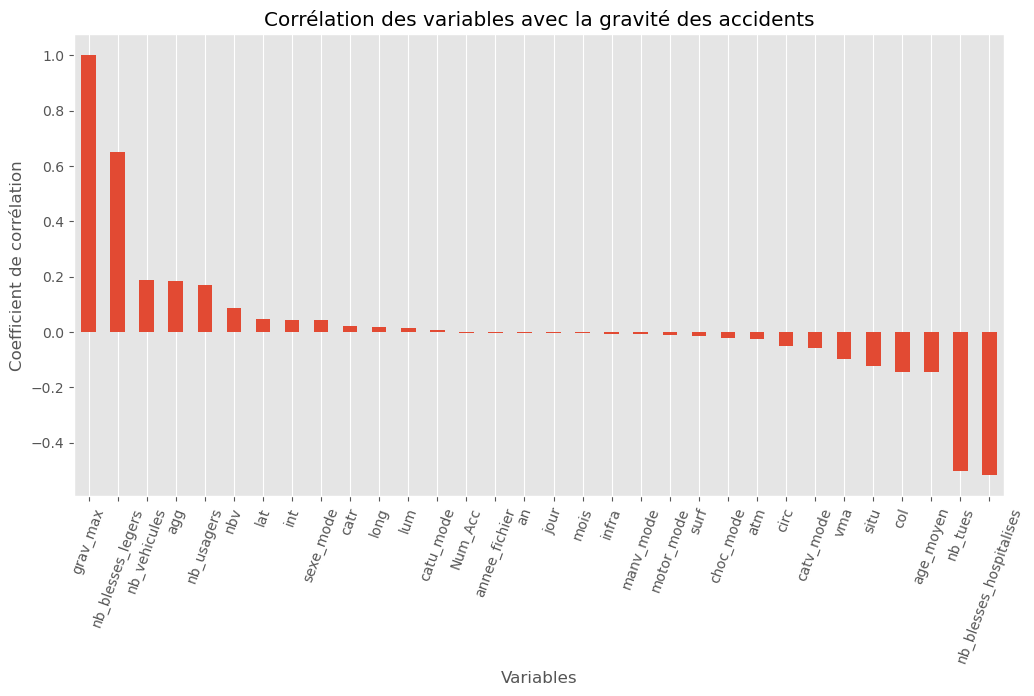

In [221]:
# Graphique des corrélations avec la gravité
corr_gravite.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Corrélation des variables avec la gravité des accidents")

plt.xlabel("Variables")
plt.ylabel("Coefficient de corrélation")

plt.xticks(rotation=70)

plt.grid(axis="y")

plt.show()

# Dans mon dataset, certaines variables sont construites directement à partir de la gravité, par exemple :
# nb_tues
# nb_blesses_hospitalises
# nb_blesses_legers
# Elles auront naturellement une très forte corrélation avec grav_max. Pour une analyse plus pertinente des facteurs
# de risque, il est préférable de les exclure.
variables = [
    "lum",
    "agg",
    "int",
    "atm",
    "col",
    "catr",
    "circ",
    "nbv",
    "vma",
    "surf",
    "infra",
    "situ",
    "nb_vehicules",
    "catv_mode",
    "choc_mode",
    "manv_mode",
    "motor_mode",
    "nb_usagers",
    "age_moyen",
    "sexe_mode",
    "catu_mode",
    "grav_max"
]

matrice_corr = dataset[variables].corr(numeric_only=True)

**Interprétation** : Cette figure présente les coefficients de corrélation entre les variables du jeu de données et la gravité des accidents. Sans surprise, grav_max affiche une corrélation parfaite (1), puisqu'elle représente directement la gravité de l'accident. Les variables nombre de blessés légers, nombre de véhicules, type de zone (agg) et nombre d'usagers présentent des corrélations positives modérées, indiquant une association avec des accidents plus graves. À l'inverse, le nombre de tués, l'âge moyen, la collision (col) et la situation (situ) présentent les corrélations négatives les plus marquées. La majorité des autres variables ont des coefficients proches de zéro, ce qui traduit une faible relation linéaire avec la gravité des accidents. 
Ces résultats suggèrent qu'aucune variable, à l'exception de grav_max, n'explique à elle seule la gravité des accidents et qu'une approche multivariée est nécessaire pour améliorer la prédiction.

**MACHINE LEARNING**

**Objectif du modèle** : Peut-on prédire si un accident sera mortel à partir de ses caractéristiques ?

In [222]:
# Créons la variable cible (gravite_accident)
dataset["accident_mortel"] = (
    dataset["gravite_accident"] == "Décès"
).astype(int)

dataset["accident_mortel"].value_counts()

accident_mortel
0    308930
1     18698
Name: count, dtype: int64

In [223]:
# Les variables explicatives
features = [
    "mois",
    "jour",
    "heure",
    "lum",
    "agg",
    "int",
    "atm",
    "col",
    "catr",
    "circ",
    "nbv",
    "vma",
    "surf",
    "infra",
    "situ",
    "nb_vehicules",
    "catv_mode",
    "choc_mode",
    "manv_mode",
    "motor_mode",
    "nb_usagers",
    "age_moyen",
    "sexe_mode",
    "catu_mode"
]

In [224]:
# Créons X et y
X = dataset[features]

y = dataset["accident_mortel"]

In [225]:
# Vérification
print(X.shape)
print(y.shape)

(327628, 24)
(327628,)


In [226]:
# Vérifions les valeurs manquantes
X.isna().sum().sort_values(ascending=False)

mois            0
jour            0
sexe_mode       0
age_moyen       0
nb_usagers      0
motor_mode      0
manv_mode       0
choc_mode       0
catv_mode       0
nb_vehicules    0
situ            0
infra           0
surf            0
vma             0
nbv             0
circ            0
catr            0
col             0
atm             0
int             0
agg             0
lum             0
heure           0
catu_mode       0
dtype: int64

In [227]:
# Vérifions les types
X.dtypes

mois              int64
jour              int64
heure             int32
lum               int64
agg               int64
int               int64
atm               int64
col               int64
catr              int64
circ              int64
nbv             float64
vma             float64
surf              int64
infra             int64
situ              int64
nb_vehicules      int64
catv_mode         int64
choc_mode         int64
manv_mode         int64
motor_mode        int64
nb_usagers        int64
age_moyen       float64
sexe_mode         int64
catu_mode         int64
dtype: object

In [228]:
# Encodage les variables catégorielles
X = pd.get_dummies(
    X,
    columns=[
        "lum",
        "agg",
        "int",
        "atm",
        "col",
        "catr",
        "circ",
        "surf",
        "infra",
        "situ",
        "catv_mode",
        "choc_mode",
        "manv_mode",
        "motor_mode",
        "catu_mode"
    ],
    drop_first=True
)

In [229]:
# Vérification
X.shape

(327628, 154)

In [230]:
# Séparation train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [231]:
# Standardisons les variables quantitatives
from sklearn.preprocessing import StandardScaler

colonnes_numeriques = [
    "jour",
    "mois",
    "heure",
    "nbv",
    "vma",
    "nb_vehicules",
    "nb_usagers",
    "age_moyen"
]

scaler = StandardScaler()

X_train[colonnes_numeriques] = scaler.fit_transform(
    X_train[colonnes_numeriques]
)

X_test[colonnes_numeriques] = scaler.transform(
    X_test[colonnes_numeriques]
)

In [232]:
# Importation des bibliothèques
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [233]:
# Entraînement du modèle
modele_log = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modele_log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [234]:
# Faisons les prédictions
y_pred = modele_log.predict(X_test)

In [235]:
# Calculons l'accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))

Accuracy : 0.9426


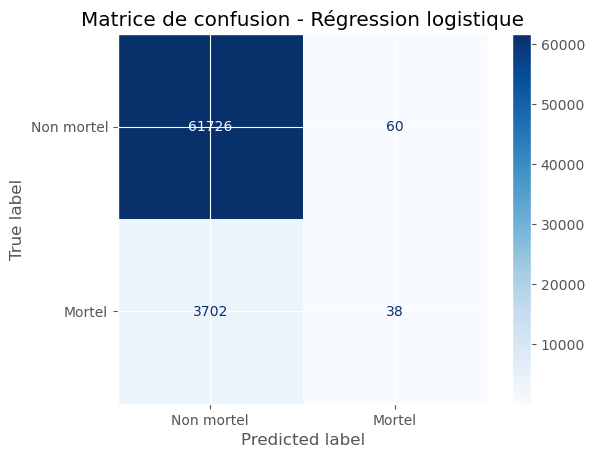

In [236]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non mortel", "Mortel"]
)

disp.plot(cmap="Blues")

plt.title("Matrice de confusion - Régression logistique")

plt.show()

**Interprétation** : La matrice de confusion de la régression logistique montre que le modèle classe correctement 61 726 accidents non mortels, contre seulement 38 accidents mortels correctement identifiés. Il génère 60 faux positifs, c'est-à-dire des accidents non mortels prédits comme mortels, mais surtout 3 702 faux négatifs, correspondant à des accidents mortels classés à tort comme non mortels. Le modèle est donc très performant pour reconnaître les accidents non mortels, mais il détecte très mal les accidents mortels. Cette situation s'explique principalement par le fort déséquilibre des classes, les accidents mortels étant beaucoup moins nombreux que les accidents non mortels. Ainsi, malgré une accuracy élevée (94,26 %), la régression logistique n'est pas adaptée, dans sa configuration actuelle, à la détection des accidents mortels et nécessite des techniques de rééquilibrage ou d'optimisation pour améliorer ses performances sur cette classe.

In [237]:
# Indicateurs de performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     61786
           1       0.39      0.01      0.02      3740

    accuracy                           0.94     65526
   macro avg       0.67      0.50      0.50     65526
weighted avg       0.91      0.94      0.92     65526



**Analyse** : La régression logistique obtient une accuracy élevée de 94 %, principalement grâce à sa bonne classification des accidents non mortels. En revanche, elle présente un rappel très faible (1 %) pour les accidents mortels, ce qui signifie qu'elle détecte très peu de ces événements. Le F1-score de 0,02 pour la classe « mortel » confirme ses faibles performances sur cette catégorie. Ces résultats montrent que le modèle est fortement influencé par le déséquilibre des classes.

In [238]:
# Importance des variables
coef = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": modele_log.coef_[0]
})

coef = coef.sort_values("Coefficient", ascending=False)

coef.head(15)

,Variable,Coefficient
99,catv_mode_39,1.403589
89,catv_mode_21,1.061278
84,catv_mode_14,0.876351
87,catv_mode_17,0.844277
22,int_8,0.797809
33,col_1,0.722369
85,catv_mode_15,0.693271
64,infra_4,0.652600
40,catr_2,0.614767
48,circ_2,0.562394


**Remarque** : Les coefficients positifs indiquent les variables associées à une probabilité plus élevée d'un accident mortel, tandis que les coefficients négatifs indiquent les variables associées à une probabilité plus faible.

1. **Performance globale du modèle**

La régression logistique obtient une accuracy de 94,26 %.

À première vue, cette valeur semble indiquer que le modèle est très performant. En effet, il classe correctement plus de 94 % des accidents du jeu de test.

Cependant, l'accuracy seule ne suffit pas pour évaluer un modèle de classification lorsque les classes sont déséquilibrées, comme c'est le cas ici.

2. **Analyse des performances par classe**

Le rapport de classification est le suivant :

Classe	Precision	Recall	F1-score	Support
Non mortel	0,94	1,00	0,97	61 786
Mortel	    0,39	0,01	0,02	3 740
Classe « Non mortel »

Le modèle obtient d'excellents résultats :

Précision : 94 %
Recall : 100 %
F1-score : 97 %

Cela signifie qu'il identifie correctement presque tous les accidents non mortels.

Classe « Mortel »

Les performances sont beaucoup plus faibles :

Précision : 39 %
Recall : 1 %
F1-score : 2 %

Le rappel (Recall) de 1 % indique que le modèle ne détecte qu'une très faible proportion des accidents mortels.

Autrement dit, la quasi-totalité des accidents mortels est classée comme non mortelle.

3. **Analyse de la matrice de confusion**

La matrice de confusion montre les résultats suivants :

Réalité	Prédit non mortel	Prédit mortel
Non mortel	61 726	60
Mortel	   3 702	38

Le modèle :

identifie correctement 61 726 accidents non mortels ;
détecte seulement 38 accidents mortels ;
classe 3 702 accidents mortels comme non mortels.

Le principal problème est donc le nombre très élevé de faux négatifs (accidents mortels non détectés).

NB : Ces résultats s'expliquent principalement par le déséquilibre du jeu de données.

Dans la base BAAC :

les accidents non mortels sont largement majoritaires ;
les accidents mortels représentent une faible proportion des observations.

Lors de l'entraînement, la régression logistique privilégie naturellement la classe majoritaire afin de maximiser l'accuracy globale. Elle apprend donc à prédire presque systématiquement la classe "Non mortel"

En conclusion, La régression logistique constitue un bon modèle de référence grâce à sa simplicité et à son interprétabilité. Elle obtient une excellente précision globale (94,26 %), mais cette performance masque une incapacité à détecter correctement les accidents mortels (Recall = 1 %).

Par conséquent, ce modèle n'est pas adapté à la prédiction des accidents mortels dans l'état actuel des données. Pour améliorer les performances, il sera nécessaire d'utiliser des modèles plus robustes, tels qu'un arbre de décision ou une forêt aléatoire (Random Forest), et éventuellement des techniques de rééquilibrage des classes (par exemple class_weight='balanced' ou SMOTE).

**ARBRE DE DECISION**

In [240]:
# Importons les bibliothèques
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [241]:
# Créons le modèle
dt = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

In [242]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [243]:
# Faisons les prédictions
y_pred_dt = dt.predict(X_test)

In [244]:
# Calculons l'accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", round(accuracy_dt, 4))

Accuracy : 0.9425


In [245]:
# Affichons le rapport de classification
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     61786
           1       0.38      0.01      0.02      3740

    accuracy                           0.94     65526
   macro avg       0.66      0.51      0.50     65526
weighted avg       0.91      0.94      0.92     65526



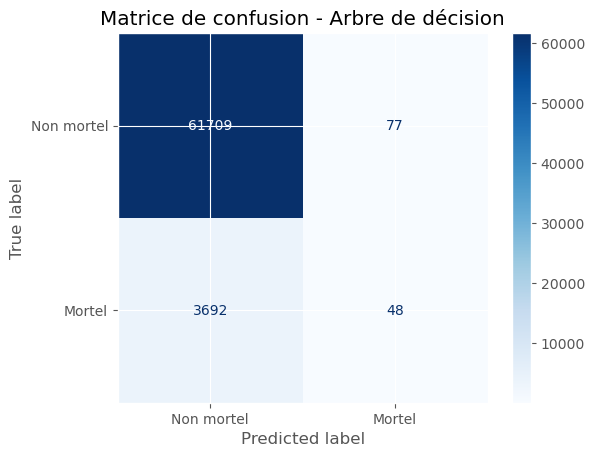

In [246]:
# Affichons la matrice de confusion
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Non mortel", "Mortel"]
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Arbre de décision")
plt.show()

**Interprétation** : L'arbre de décision obtient une accuracy de 94,25 %, ce qui indique une bonne performance globale. Toutefois, cette performance est principalement due à la bonne prédiction des accidents non mortels, qui sont largement majoritaires dans le jeu de données. Pour cette classe, le modèle présente une précision de 94 %, un rappel de 100 % et un F1-score de 97 %. En revanche, ses performances sont très faibles pour les accidents mortels : la précision est de 38 %, le rappel de seulement 1 % et le F1-score de 2 %. Cela signifie que le modèle identifie très peu d'accidents mortels et les confond le plus souvent avec des accidents non mortels. Ainsi, malgré une excellente accuracy, l'arbre de décision n'est pas adapté, dans sa configuration actuelle, à la détection des accidents mortels.

**RANDOM FOREST**

In [247]:
# ImportONS les bibliothèques
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [248]:
# Créons le modèle
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [249]:
# Entraînons le modèle
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [250]:
# Faisons les prédictions
y_pred_rf = rf.predict(X_test)

In [251]:
# Évaluons le modèle
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy :", round(accuracy_rf, 4))

Accuracy : 0.9429


In [252]:
# Rapport de classification
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     61786
           1       0.49      0.02      0.04      3740

    accuracy                           0.94     65526
   macro avg       0.72      0.51      0.50     65526
weighted avg       0.92      0.94      0.92     65526



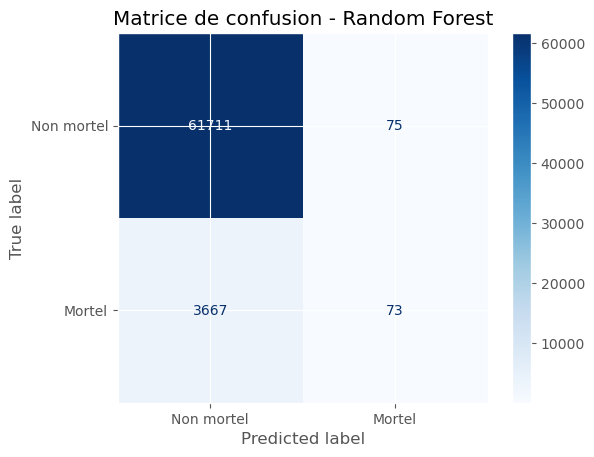

In [253]:
# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non mortel", "Mortel"]
)

disp.plot(cmap="Blues")

plt.title("Matrice de confusion - Random Forest")

plt.show()

**Interprétation** : Cette matrice de confusion du Random Forest montre que le modèle classe correctement 61 711 accidents non mortels et seulement 73 accidents mortels. Il commet 75 faux positifs, c’est-à-dire des accidents non mortels prédits comme mortels, et surtout 3 667 faux négatifs, correspondant à des accidents mortels non détectés. Le modèle est donc très performant pour identifier les accidents non mortels, mais reste peu efficace pour détecter les accidents mortels. Malgré une bonne précision globale (accuracy ≈ 94 %), la classe « Mortel » demeure fortement sous-détectée en raison du déséquilibre du jeu de données. Comparé aux modèles précédents, le Random Forest détecte davantage d’accidents mortels, mais l’amélioration reste limitée. Cette figure montre ainsi que l’accuracy seule ne suffit pas pour évaluer le modèle et qu’il est nécessaire d’améliorer le rappel de la classe « Mortel » par des techniques de rééquilibrage ou d’ajustement du seuil de décision.

In [254]:
# Importance des variables
importance_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

importance_rf.head(15)

,Variable,Importance
7,age_moyen,0.121790
1,jour,0.095130
2,heure,0.083982
0,mois,0.075841
4,vma,0.044926
6,nb_usagers,0.034712
3,nbv,0.023321
109,choc_mode_1,0.015824
8,sexe_mode,0.015157
119,manv_mode_1,0.015099


**Analyse** : L'analyse des importances montre que l'âge moyen des usagers est la variable la plus influente (12,18 %), suivi des variables temporelles (jour, heure et mois), ce qui souligne le rôle des périodes de circulation dans la gravité des accidents. La vitesse maximale autorisée (vma) et le nombre d'usagers figurent également parmi les facteurs les plus importants. Les caractéristiques du véhicule et de l'accident (type de choc, type de véhicule, type de route, manœuvre) contribuent aussi à la prédiction, mais avec une influence plus modérée. Ces résultats indiquent que la gravité des accidents dépend d'une combinaison de facteurs démographiques, temporels, routiers et liés aux circonstances de l'accident.

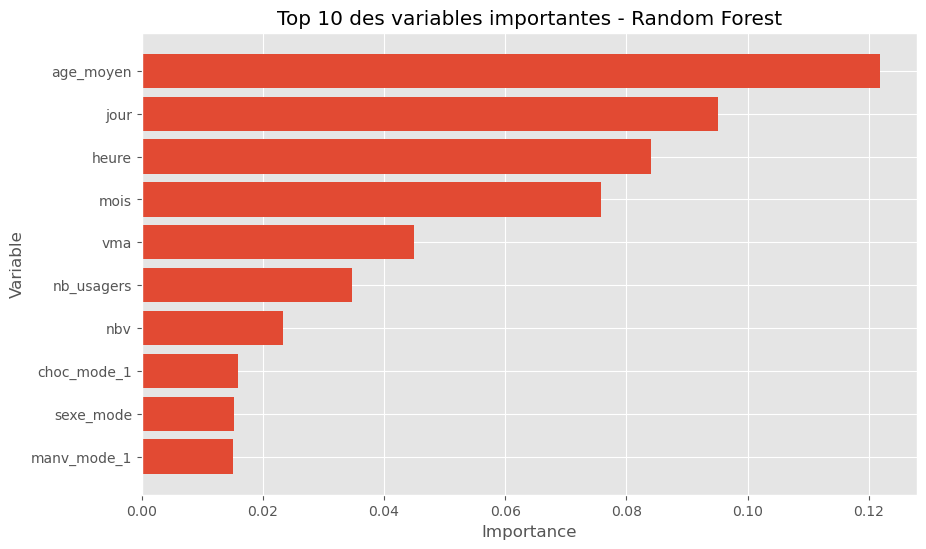

In [255]:
# Visualisons les variables les plus importantes
top10 = importance_rf.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Variable"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 des variables importantes - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.show()

**Interprétation** : La figure présente les 10 variables les plus importantes utilisées par le modèle Random Forest pour prédire les accidents mortels. L'âge moyen des usagers apparaît comme le facteur le plus influent, ce qui suggère que l'âge joue un rôle majeur dans la gravité des accidents. Les variables jour, heure et mois occupent également une place importante, mettant en évidence l'influence des facteurs temporels sur le risque d'accident mortel. La vitesse maximale autorisée (vma) ainsi que le nombre d'usagers impliqués contribuent également à la prédiction. Les variables liées aux circonstances de l'accident, telles que le type de choc, la manœuvre effectuée, le sexe dominant et le nombre de voies, ont une influence plus faible mais restent pertinentes. Dans l'ensemble, le modèle montre que la gravité des accidents résulte d'une combinaison de facteurs démographiques, temporels, routiers et comportementaux.

**CONCLUSION GENERALE**

L'analyse exploratoire des accidents corporels survenus en France entre 2019 et 2024 met en évidence plusieurs tendances majeures concernant la fréquence, la gravité et les facteurs associés aux accidents routiers. Les résultats montrent tout d'abord que le nombre d'accidents a fortement diminué en 2020, conséquence directe des restrictions de déplacement liées à la pandémie de COVID-19, avant de retrouver un niveau proche de celui d'avant-crise dès 2021. Depuis, les volumes d'accidents et d'accidents mortels restent relativement stables.

Les analyses spatiales révèlent que les voies communales et les routes départementales concentrent la majorité des accidents, ce qui s'explique par leur forte fréquentation quotidienne. Les départements fortement urbanisés, notamment Paris et plusieurs départements d'Île-de-France, figurent parmi les territoires les plus accidentogènes. De même, les grandes agglomérations concentrent un nombre élevé d'accidents en raison de la densité de circulation.

Les analyses temporelles montrent que les accidents sont plus fréquents en fin de semaine, avec un pic observé le vendredi, tandis que le dimanche enregistre le plus faible nombre d'accidents. Cette évolution traduit probablement une intensification des déplacements professionnels et personnels avant le week-end.

Concernant les facteurs environnementaux, la majorité des accidents surviennent par temps normal et sur une chaussée sèche. Cela ne signifie pas que ces conditions sont plus dangereuses, mais qu'elles correspondent aux situations de circulation les plus fréquentes. Les épisodes de pluie, de brouillard, de neige ou de verglas restent minoritaires, bien qu'ils puissent accroître le risque individuel d'accident.

L'étude met également en évidence que les voitures particulières sont impliquées dans la grande majorité des accidents mortels, suivies à une distance importante par les utilitaires, les motocyclettes et les poids lourds. Les hommes apparaissent largement surreprésentés dans les accidents mortels, tandis que l'âge moyen des victimes décédées est supérieur à celui des blessés, suggérant une vulnérabilité accrue des personnes plus âgées.

Les analyses statistiques montrent que certaines variables, notamment l'âge moyen, le jour, l'heure, le mois, la vitesse maximale autorisée et le nombre d'usagers, jouent un rôle important dans l'explication de la gravité des accidents. En revanche, la matrice de corrélation révèle peu de relations linéaires fortes entre les variables explicatives, ce qui confirme que la gravité des accidents résulte de l'interaction de nombreux facteurs.

Enfin, les modèles prédictifs soulignent les difficultés à détecter les accidents mortels en raison du fort déséquilibre entre les classes. Malgré une excellente performance pour identifier les accidents non mortels, les modèles restent peu efficaces pour prédire les accidents mortels, ce qui montre la nécessité de recourir à des techniques de rééquilibrage des données et à des modèles plus adaptés.

Dans l'ensemble, cette étude fournit une vision globale des caractéristiques des accidents routiers en France entre 2019 et 2024. Les résultats obtenus permettent d'identifier les principaux facteurs de risque, de mieux comprendre les contextes dans lesquels surviennent les accidents les plus graves et d'apporter des éléments d'aide à la décision pour orienter les politiques de prévention et renforcer les actions en faveur de la sécurité routière.

**Recommandations**

Au regard des résultats obtenus, plusieurs recommandations peuvent être formulées afin de contribuer à la réduction du nombre et de la gravité des accidents routiers en France.

1. *Renforcer les contrôles routiers aux périodes les plus accidentogènes*, notamment le vendredi, les heures de pointe et les périodes de forte affluence, afin de limiter les comportements à risque (excès de vitesse, alcool, stupéfiants, distraction au volant).

2. *Améliorer la sécurité des routes départementales et des voies communales*, qui concentrent la majorité des accidents, par des aménagements adaptés : meilleure signalisation, entretien des chaussées, éclairage, sécurisation des intersections et limitation des points dangereux.

3. *Renforcer les mesures de prévention sur les axes à vitesse élevée*, en développant les dispositifs de contrôle de vitesse (radars, contrôles mobiles) et en adaptant les limitations de vitesse dans les zones identifiées comme les plus accidentogènes.

4. *Développer des actions de sensibilisation ciblées auprès des conducteurs de voitures particulières*, principal type de véhicule impliqué dans les accidents mortels, afin de promouvoir une conduite plus prudente et responsable.

5. *Mettre en place des campagnes de prévention spécifiques destinées aux hommes*, davantage représentés parmi les victimes d'accidents mortels, en insistant sur les risques liés à la vitesse, à l'alcool, à la fatigue et aux comportements dangereux.

6. *Renforcer la protection des usagers les plus vulnérables*, notamment les personnes âgées, en améliorant la signalisation, les infrastructures piétonnes et cyclables, ainsi que les dispositifs de sécurité aux abords des zones fréquentées.

7. *Poursuivre les campagnes nationales de sensibilisation à la sécurité routière*, en mettant l'accent sur les comportements responsables quelles que soient les conditions météorologiques, puisque la majorité des accidents surviennent par temps normal et sur chaussée sèche.

8. *Exploiter les données et l'intelligence artificielle pour anticiper les zones et périodes à risque*, afin d'aider les autorités à cibler les actions de prévention et les contrôles de manière plus efficace.

9. *Améliorer la collecte et la qualité des données d'accidents*, notamment sur les circonstances, les comportements des conducteurs et les facteurs environnementaux, afin de développer des modèles prédictifs plus performants.

10. *Développer des modèles de prédiction plus robustes*, en utilisant des techniques de rééquilibrage des données (SMOTE, pondération des classes), des méthodes d'ensemble et des algorithmes plus avancés (XGBoost, LightGBM, CatBoost), afin d'améliorer la détection des accidents mortels et de renforcer les outils d'aide à la décision pour les acteurs de la sécurité routière.

**Limites de l'étude**

Cette étude présente plusieurs limites qu'il convient de souligner. 
Premièrement, les données utilisées proviennent uniquement des accidents corporels enregistrés entre 2019 et 2024 et peuvent comporter des valeurs manquantes ou des erreurs de saisie. 
Deuxièmement, certaines variables potentiellement explicatives (alcoolémie, usage du téléphone, fatigue, vitesse réelle, état du conducteur, trafic en temps réel, etc.) ne sont pas disponibles, ce qui limite la capacité d'explication des modèles. Troisièmement, la période 2020 est fortement marquée par la pandémie de COVID-19, dont les restrictions de déplacement ont modifié de manière exceptionnelle les comportements de mobilité. 
Par ailleurs, la variable cible étant fortement déséquilibrée (les accidents mortels étant beaucoup moins nombreux que les accidents non mortels), les performances des modèles de classification, notamment de la régression logistique, restent limitées pour détecter correctement les accidents mortels. En outre, les analyses réalisées reposent principalement sur des corrélations et des modèles prédictifs, sans permettre d'établir des relations de causalité. Enfin, les résultats obtenus sont spécifiques au jeu de données étudié et doivent être interprétés avec prudence avant toute généralisation à d'autres périodes ou contextes géographiques.

In [261]:
# Exporter le jeu de données nettoyé
dataset.to_csv("donnees_accidents_nettoyees_2019_2024.csv", index=False, encoding="utf-8-sig")

In [262]:
# Format Excel
dataset.to_excel("donnees_accidents_nettoyees_2019_2024.xlsx", index=False)